 ### Project description

 The online store Ice sells video games all over the world. User and expert reviews, genres, platforms (e.g. Xbox or PlayStation), and historical data on game sales are available from open sources.



 We need to identify patterns that determine whether a game succeeds or not. This will allow us to spot potential big winners and plan advertising campaigns.

 ### Importing libraries

In [1]:
# %%
import plotly.express as px
import pandas as pd
#import sidetable as stb
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from functools import reduce
from scipy import stats
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
pd.options.display.float_format = '{:.2f}'.format


 ### Reading and studying the data

In [2]:
# %%
games = pd.read_csv('https://code.s3.yandex.net/datasets/games.csv')
games.head()

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.00,Sports,41.36,28.96,3.77,8.45,76.00,8,E
1,Super Mario Bros.,NES,1985.00,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.00,Racing,15.68,12.76,3.79,3.29,82.00,8.3,E
3,Wii Sports Resort,Wii,2009.00,Sports,15.61,10.93,3.28,2.95,80.00,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.00,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [9]:
games.columns = games.columns.str.lower()

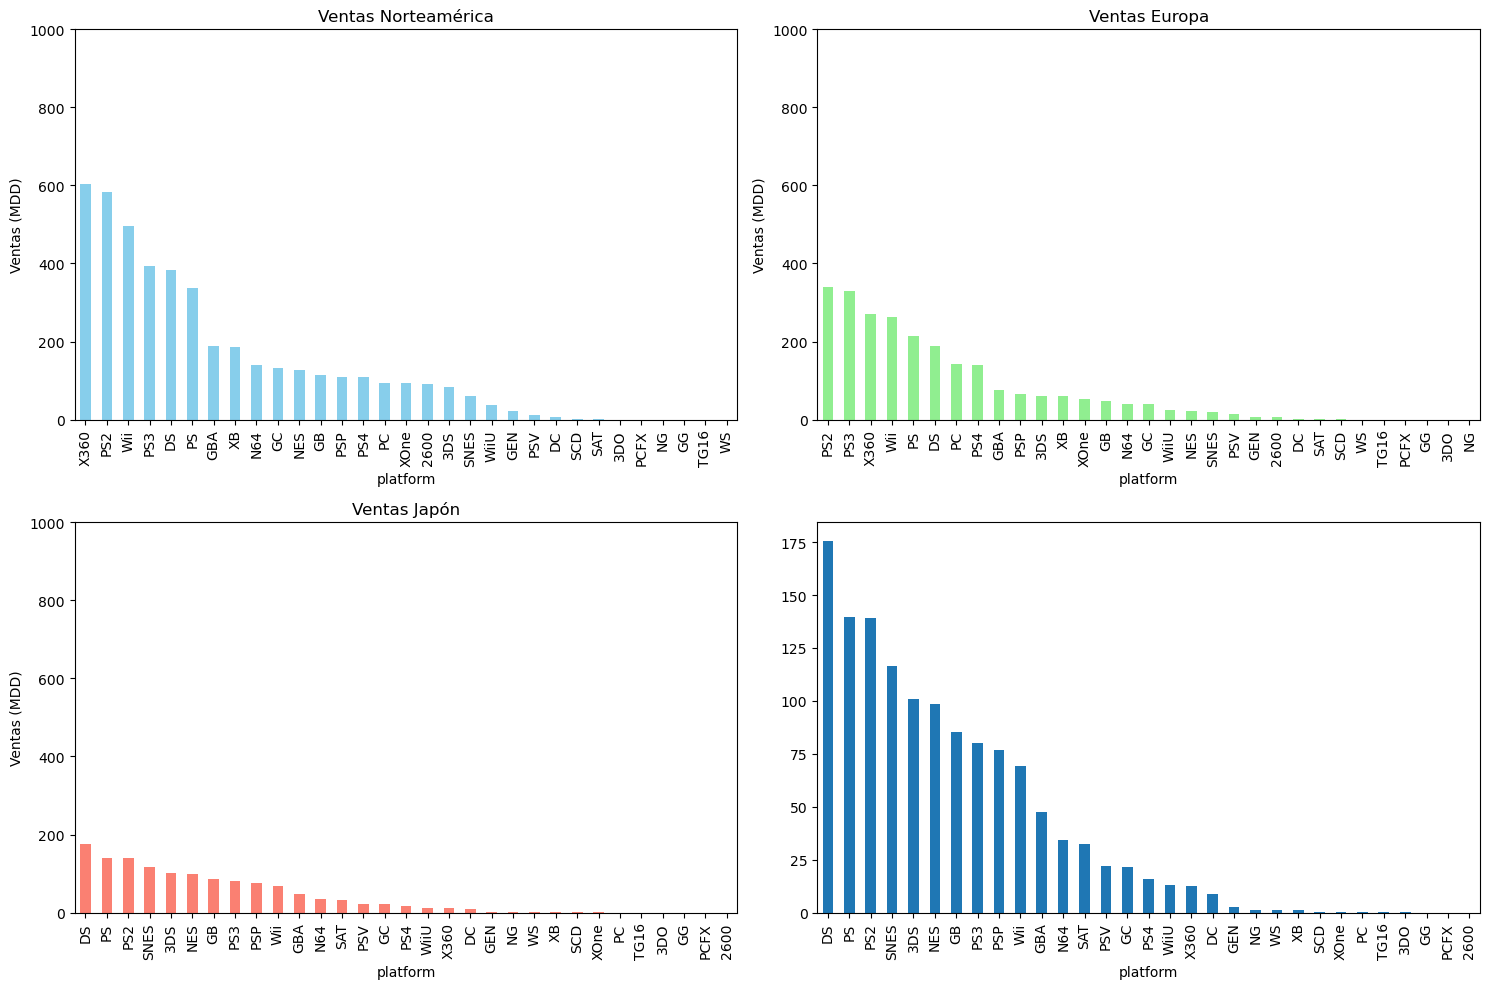

In [22]:
x = games.groupby('platform')['na_sales'].sum().sort_values(ascending=False)
y = games.groupby('platform')['eu_sales'].sum().sort_values(ascending=False)
z = games.groupby('platform')['jp_sales'].sum().sort_values(ascending=False)
best_platform_sales = z

fig, axs = plt.subplots(2, 2, figsize=(15, 10)) 

x.plot(kind='bar', title="Ventas Norteamérica", ylabel='Ventas (MDD)', color='skyblue', ax=axs[0, 0])
axs[0, 0].set_ylim(0, 1000)

y.plot(kind='bar', title="Ventas Europa", ylabel='Ventas (MDD)', color='lightgreen', ax=axs[0, 1])
axs[0, 1].set_ylim(0, 1000)

z.plot(kind='bar', title="Ventas Japón", ylabel='Ventas (MDD)', color='salmon', ax=axs[1, 0])
axs[1, 0].set_ylim(0, 1000)

#best_platform_sales.set_index('platform').plot(kind='bar', legend=False, ax=axs[1, 1])
best_platform_sales.plot(kind='bar', legend=False, ax=axs[1, 1])

plt.tight_layout()
plt.show();

In [3]:
# %%
data
data.info()
data.describe()


,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.00,Sports,41.36,28.96,3.77,8.45,76.00,8,E
1,Super Mario Bros.,NES,1985.00,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.00,Racing,15.68,12.76,3.79,3.29,82.00,8.3,E
3,Wii Sports Resort,Wii,2009.00,Sports,15.61,10.93,3.28,2.95,80.00,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.00,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016.00,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16711,LMA Manager 2007,X360,2006.00,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN
16712,Haitaka no Psychedelica,PSV,2016.00,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16713,Spirits & Spells,GBA,2003.00,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


,Year_of_Release,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score
count,16446.00,16715.00,16715.00,16715.00,16715.00,8137.00
mean,2006.48,0.26,0.15,0.08,0.05,68.97
std,5.88,0.81,0.50,0.31,0.19,13.94
min,1980.00,0.00,0.00,0.00,0.00,13.00
25%,2003.00,0.00,0.00,0.00,0.00,60.00
50%,2007.00,0.08,0.02,0.00,0.01,71.00
75%,2010.00,0.24,0.11,0.04,0.03,79.00
max,2016.00,41.36,28.96,10.22,10.57,98.00


In [4]:
# %%
data.duplicated().sum()
data.stb.missing(style=True)


0

,missing,total,percent
Critic_Score,"8,578","16,715",51.32%
Rating,"6,766","16,715",40.48%
User_Score,"6,701","16,715",40.09%
Year_of_Release,269,"16,715",1.61%
Name,2,"16,715",0.01%
Genre,2,"16,715",0.01%
Platform,0,"16,715",0.00%
NA_sales,0,"16,715",0.00%
EU_sales,0,"16,715",0.00%
JP_sales,0,"16,715",0.00%


 #### Conclusion

 <div style="border:solid green 2px; padding: 20px"> <b>Success:</b><br>

     It's great that you checked for duplicates in the dataset and made sure there were none.  I like that you use a variety of methods when studying general information in table. Good job!</div>

 The initial dataset is comprised of 16,715 rows and 11 columns. We can see that we'll need to normalize column names. We identified missing values (up to 51%) in different columns and we found no duplicates. The data types are mostly OK except for Year_of_release and User_score columns.

 ### Preparing the data

 #### Lowering headers case and dealing with the missing values

In [ ]:
# %%
data.columns = data.columns.str.lower()
#data['year_of_release'] = data['year_of_release'].fillna(0).astype('int')
data.loc[data['user_score'] == 'tbd', 'user_score'] = np.nan
data['user_score'] = data['user_score'].astype('float')
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16715 non-null  int64  
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           9949 non-null   object 
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [ ]:
#IRA: rellenar dependiendo de la plataforma
nan = {
    '2600': 1982,
    '3DS': 2013,
    'DS': 2008,
    'GB': 1995,
    'GBA': 2003,
    'GC': 2003,
    'N64': 1998,
    'PC': 2008,
    'PS': 1998,
    'PS2': 2004,
    'PS3': 2010,
    'PSP': 2008,
    'PSV': 2008,
    'Wii': 2008,
    'X360': 2009,
    'XB': 2003
}

for platform, year in nan.items():
    condicion = (df['platform'] == platform) & (df['year_of_release'].isna())
    df.loc[condicion, 'year_of_release'] = year

print(df['year_of_release'].isna().sum())


 <div style="border:solid green 2px; padding: 20px"> <b>Success:</b><br>

     Very well that you converted the columns to lower case using <code>str.lower()</code>



 Agree with your decision not to fill the missing values with the median, for example. But in this case we can just remove missing values :)</div>

In [6]:
# %%
data['rating'].unique()


array(['E', nan, 'M', 'T', 'E10+', 'K-A', 'AO', 'EC', 'RP'], dtype=object)

 #### Calculating total sales revenue

In [7]:
# %%
data['total_sales'] = data[['na_sales', 'eu_sales',
                            'jp_sales', 'other_sales']].sum(axis=1)
data.nlargest(5, ['total_sales'])
data.info()


,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.00,8.00,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.00,8.30,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.00,8.00,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN,31.38


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16715 non-null  int64  
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           9949 non-null   object 
 11  total_sales      16715 non-null  float64
dtypes: float64(7), int64(1), object(4)
memory usage: 1.5+ MB


 <div style="border:solid green 2px; padding: 20px"> <b>Success:</b><br>



    `total_sales` is calculated correctly. Thanks for using `sum(axis=1)`. This way your code looks more professionally.





 </div>



 #### Conclusion

 We lowered the case for headers and changed data type for Year_of_release column.

 We dealt with the missing values in the following way:



    *Year_of_release*: We don't have many missing values here so we changed them to zero as it doesn't affect the results of our analysis.



    *Critic_score*: there's nothing we can do to fill it in so we leave the missing values as they are.



    *User_score*: again there's nothing we can do to fill in missing values or values for games where rating is pending ('tbd'). We changed 'tbd' values to 'NaN' in order to change data type leave is as it is.



 We leave the other missing values as they are because those are object data types that we can not fill in. Still they might not have any visible impact on the results of our analysis.



 Finally we calculated Total_sales column as requested.

 <div style="border:solid green 2px; padding: 20px"> <b>Success:</b><br>

 Thanks for the detailed conclusions!</div>

 ### Analyzing the data

 #### Looking at games releases

In [8]:
# %%
df_count = data[
    ['year_of_release', 'name']].groupby(['year_of_release']).count().sort_values(by='name').reset_index(
)
df_count = df_count[df_count['year_of_release'] != 0]
df_count


,year_of_release,name
0,1980,9
1,1984,14
2,1985,14
3,1988,15
4,1987,16
5,1990,16
6,1983,17
7,1989,17
8,1986,21
9,1982,36


Text(0.5, 1.0, 'Games releases per year')

Text(0, 0.5, 'Number of games')

Text(0.5, 0, 'Year of release')

[Text(1980, 0, '1980'),
 Text(1984, 0, '1984'),
 Text(1985, 0, '1985'),
 Text(1988, 0, '1988'),
 Text(1987, 0, '1987'),
 Text(1990, 0, '1990'),
 Text(1983, 0, '1983'),
 Text(1989, 0, '1989'),
 Text(1986, 0, '1986'),
 Text(1982, 0, '1982'),
 Text(1991, 0, '1991'),
 Text(1992, 0, '1992'),
 Text(1981, 0, '1981'),
 Text(1993, 0, '1993'),
 Text(1994, 0, '1994'),
 Text(1995, 0, '1995'),
 Text(1996, 0, '1996'),
 Text(1997, 0, '1997'),
 Text(1999, 0, '1999'),
 Text(2000, 0, '2000'),
 Text(1998, 0, '1998'),
 Text(2001, 0, '2001'),
 Text(2016, 0, '2016'),
 Text(2013, 0, '2013'),
 Text(2014, 0, '2014'),
 Text(2015, 0, '2015'),
 Text(2012, 0, '2012'),
 Text(2004, 0, '2004'),
 Text(2003, 0, '2003'),
 Text(2002, 0, '2002'),
 Text(2005, 0, '2005'),
 Text(2006, 0, '2006'),
 Text(2011, 0, '2011'),
 Text(2007, 0, '2007'),
 Text(2010, 0, '2010'),
 Text(2009, 0, '2009'),
 Text(2008, 0, '2008')]

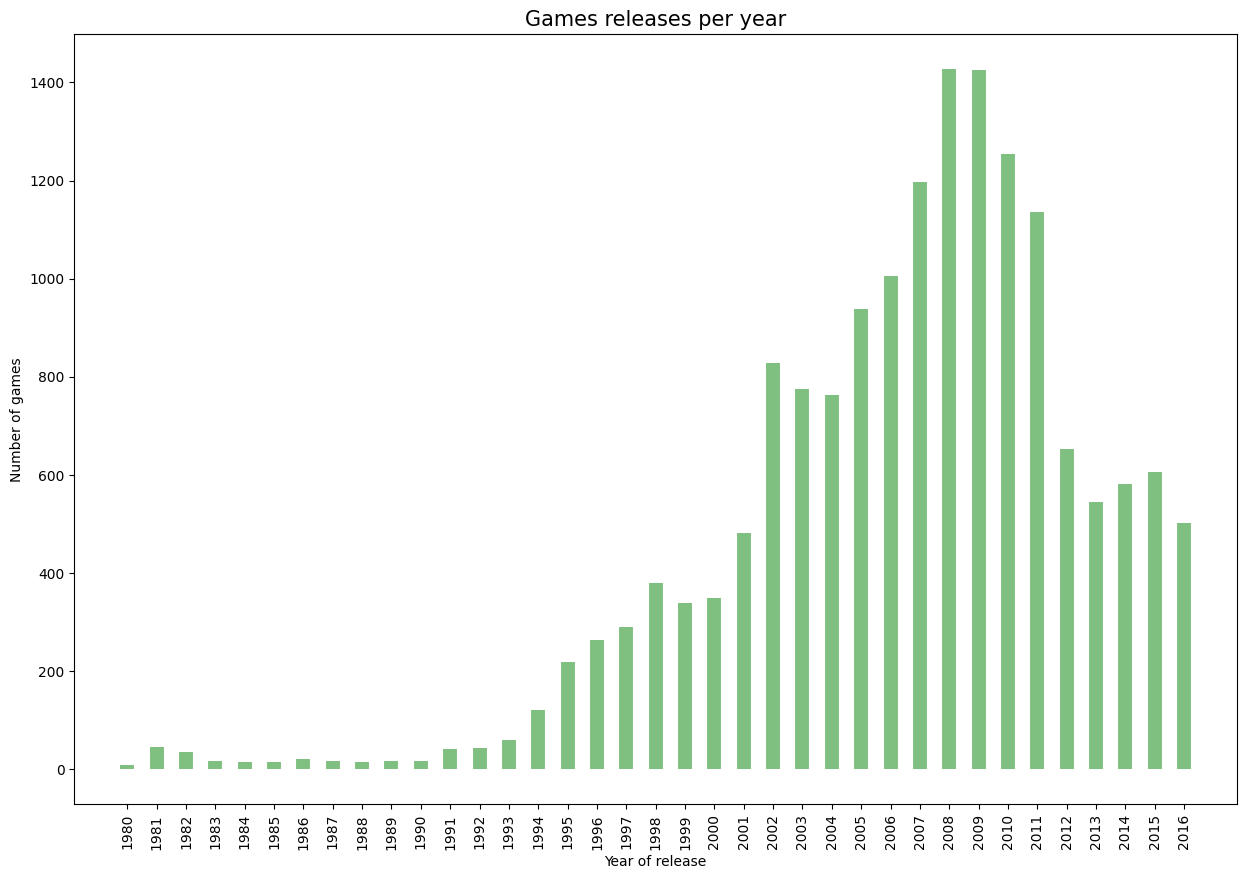

In [9]:
# %%
fig, ax = plt.subplots(figsize=(15, 10))
ax.vlines(x=df_count.year_of_release, ymin=0, ymax=df_count.name,
          alpha=0.5, linewidth=10, color='green')
ax.set_title('Games releases per year', size=15)
ax.set_ylabel('Number of games')
ax.set_xlabel('Year of release')
ax.set_xticks(df_count.year_of_release)
ax.set_xticklabels(df_count.year_of_release, rotation=90)


 **Comment:**

 *The graph shows the amount of games released per year. We can see a rapid growth in late 90's with a peack in late 2008-2009 and stagnation in 2010's.*

 #### Looking at sales distribution

In [10]:
# %%
df_sales = data[['platform', 'total_sales']].groupby(
    ['platform']).sum().sort_values(by='total_sales').reset_index(
)
df_sales['z_score'] = (df_sales['total_sales'] -
                       df_sales['total_sales'].mean())/df_sales['total_sales'].std()
df_sales['color'] = ['red' if x < 0 else 'green' for x in df_sales['z_score']]
df_sales


,platform,total_sales,z_score,color
0,PCFX,0.03,-0.83,red
1,GG,0.04,-0.83,red
2,3DO,0.10,-0.83,red
3,TG16,0.16,-0.83,red
4,WS,1.42,-0.82,red
5,NG,1.44,-0.82,red
6,SCD,1.86,-0.82,red
7,DC,15.95,-0.78,red
8,GEN,30.77,-0.74,red
9,SAT,33.59,-0.73,red


<Figure size 1500x1000 with 0 Axes>

Text(0, 0.5, 'Platform')

Text(0.5, 0, 'Z score')

Text(0.5, 1.0, 'Sales revenue per platform')

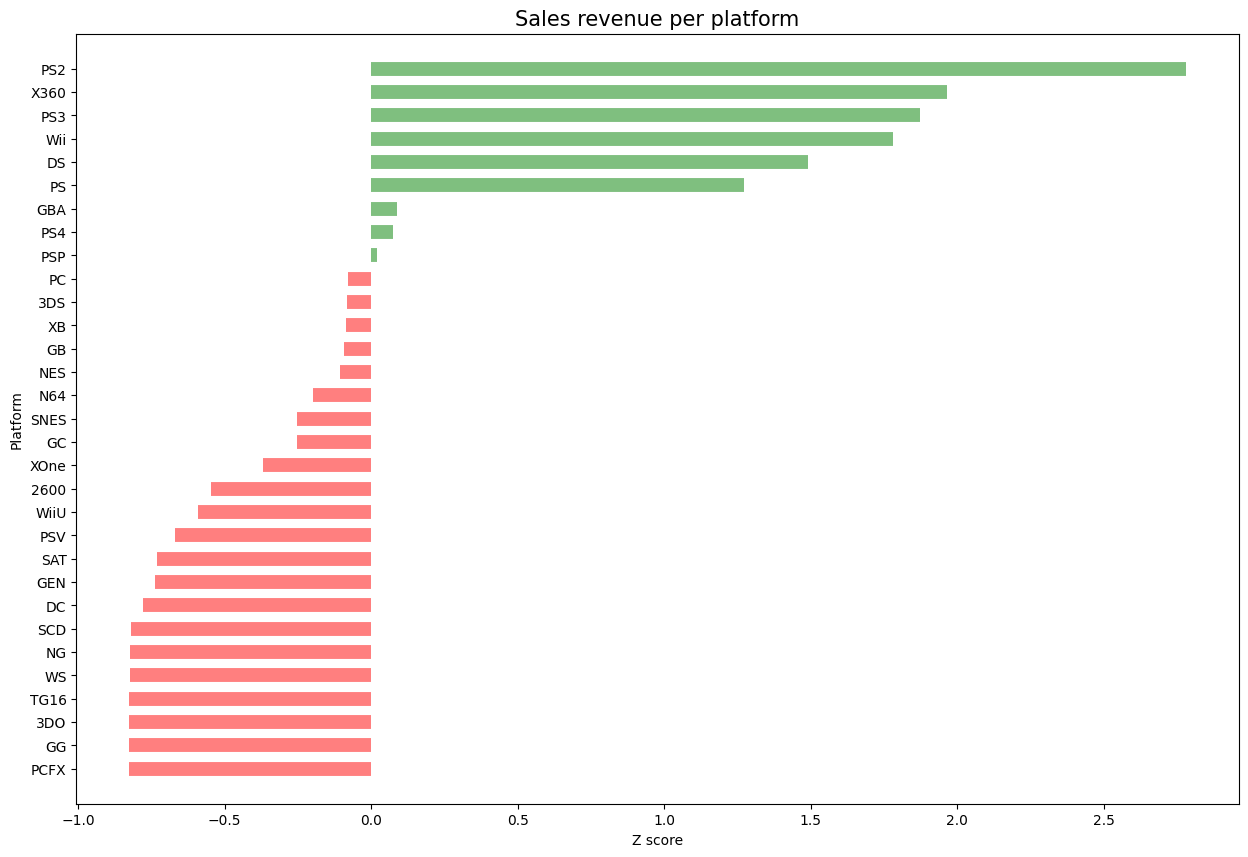

In [11]:
# %%
plt.figure(figsize=(15, 10))
plt.hlines(
    y=df_sales.platform, xmax=df_sales.z_score, xmin=0, color=df_sales.color, linewidth=10, alpha=0.5
)
plt.ylabel('Platform')
plt.xlabel('Z score')
plt.title('Sales revenue per platform', size=15)


 **Comment:**

 *Here we can see most profitable platforms (green) and less profitable (red). We calculated z_score to show how far each platform revenue is from overall mean value (z-score=0).*

 <div style="border:solid green 2px; padding: 20px"> <b>Success:</b><br>

    Wow, it's really great that you use the z-score for the determining of the most dominant platforms for the whole period 👏 👏 👏   </div>

 #### Looking at platforms lifetime

In [12]:
# %%
df_lifetime = pd.pivot_table(
    data, index='year_of_release', columns='platform', values='total_sales', aggfunc='sum').fillna(0
                                                                                                   )
df_lifetime = df_lifetime.iloc[1:, :]
df_lifetime


platform,2600,3DO,3DS,DC,DS,GB,GBA,GC,GEN,GG,...,SAT,SCD,SNES,TG16,WS,Wii,WiiU,X360,XB,XOne
year_of_release,,,,,,,,,,,,,,,,,,,,,
1980,11.38,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1981,35.68,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1982,28.88,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1983,5.84,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1984,0.27,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1985,0.45,0.00,0.00,0.00,0.02,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1986,0.67,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1987,1.94,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1988,0.74,0.00,0.00,0.00,0.00,1.43,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


<Axes: xlabel='year_of_release'>

Text(0, 0.5, 'Revenue')

Text(0.5, 0, 'Year')

Text(0.5, 1.0, 'Platforms lifetime')

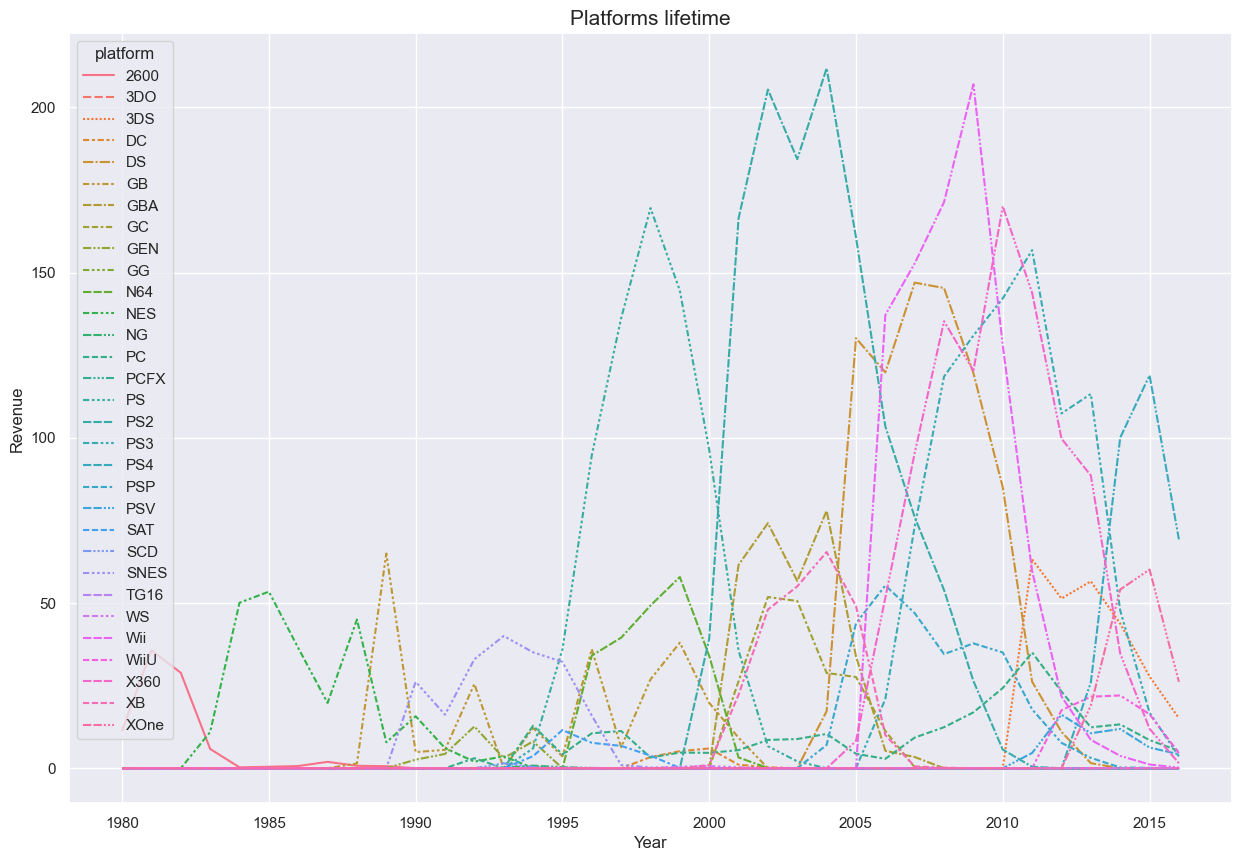

In [13]:
# %%
sns.set(rc={'figure.figsize': (15, 10)})
sns.lineplot(data=df_lifetime)
plt.ylabel('Revenue')
plt.xlabel('Year')
plt.title('Platforms lifetime', size=15)


 **Comment:**

 *This graph shows a platform lifetime from first sales to oblivion. We can see that on average popular platforms "live" for about 10 years before they fade away.*

 <div style="border:solid green 2px; padding: 20px"> <b>Success:</b><br>

   I like that you use a variety of charts in your research. </div>

 #### Choosing relevant data for analysis

In [14]:
# %%
good_data = data[data.year_of_release >= 2013]


<Axes: xlabel='year_of_release'>

Text(0, 0.5, 'Revenue')

Text(0.5, 0, 'Year')

Text(0.5, 1.0, 'New platforms lifetime')

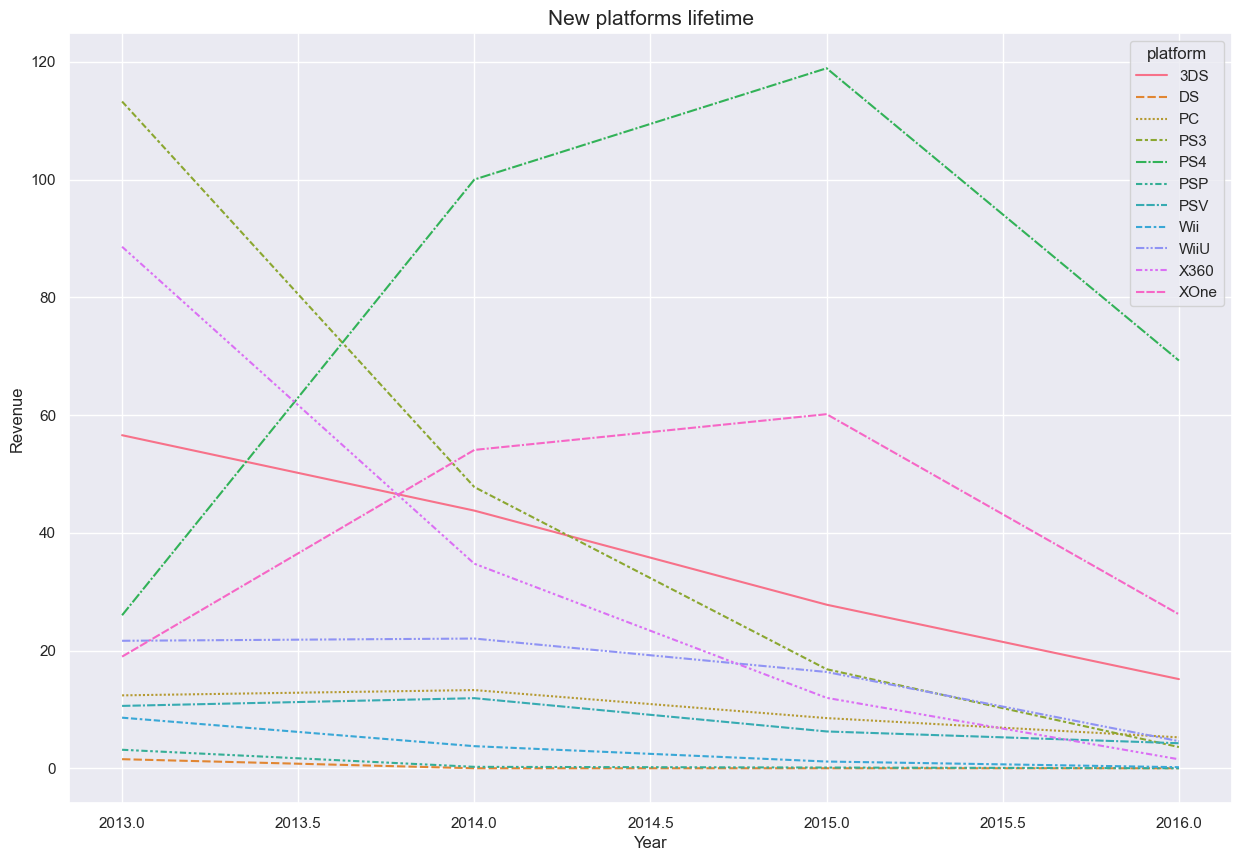

In [15]:
# %%
df_lifetime_new = pd.pivot_table(
    good_data, index='year_of_release', columns='platform', values='total_sales', aggfunc='sum').fillna(0)
sns.set(rc={'figure.figsize': (15, 10)})
sns.lineplot(data=df_lifetime_new)
plt.ylabel('Revenue')
plt.xlabel('Year')
plt.title('New platforms lifetime', size=15)


 **Comment:**

 *This graph shows platforms revenue over time within the chosen period, i.e. 2013-2016. We can see that revenue of all platforms is declining.*

In [16]:
# %%
# Reviewer's code
plot_data = good_data.groupby(['year_of_release', 'platform']).agg({
    'total_sales': 'sum'}).reset_index()

fig = px.line(plot_data, x="year_of_release", y="total_sales",
              color='platform', title="New platforms lifetime")
fig.show()


<Figure size 1500x1000 with 0 Axes>

<Axes: xlabel='platform', ylabel='total_sales'>

(0.0, 3.0)

Text(0, 0.5, 'Revenue')

Text(0.5, 0, 'Platform')

Text(0.5, 1.0, 'Revenue distribution per game')

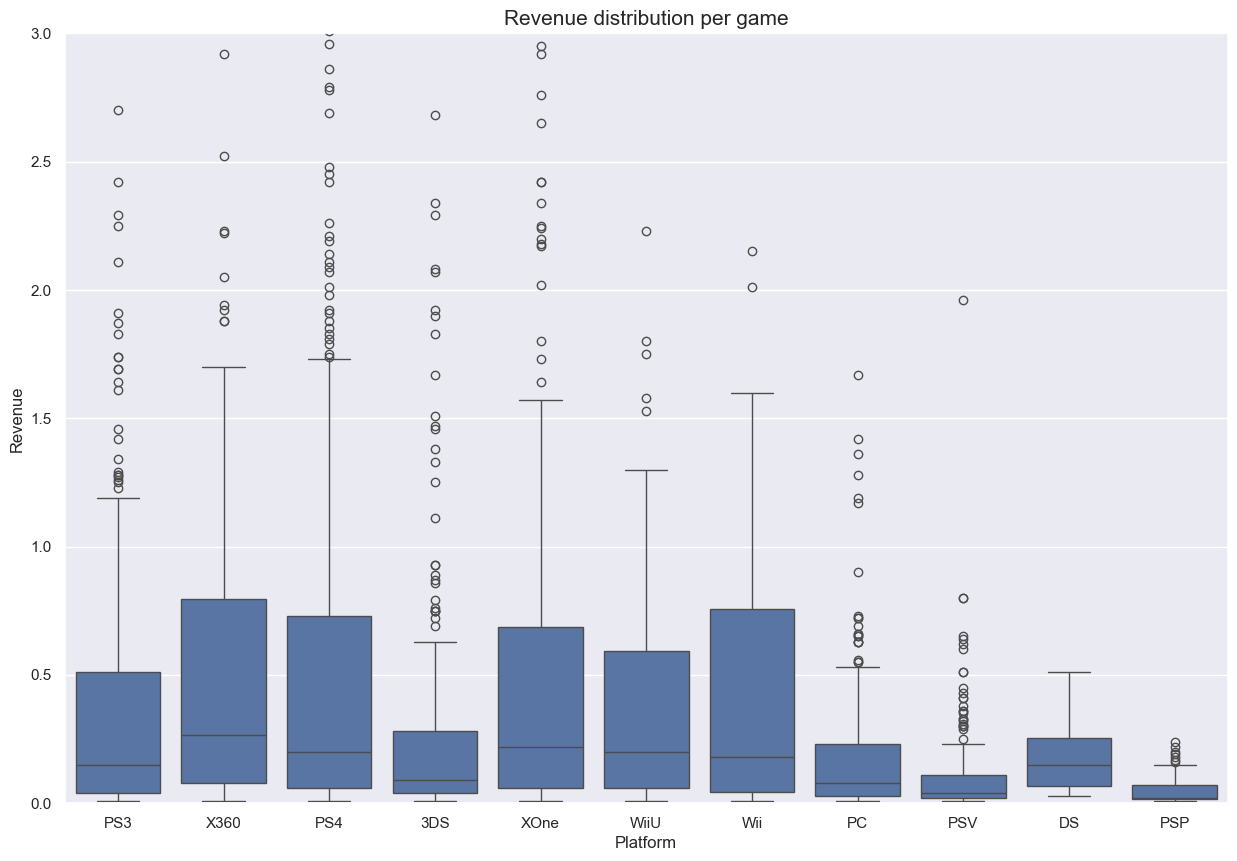

In [17]:
# %%
plt.figure(figsize=(15, 10))
sns.boxplot(x='platform', y='total_sales', data=good_data)
plt.ylim(0, 3)
plt.ylabel('Revenue')
plt.xlabel('Platform')
plt.title('Revenue distribution per game', size=15)


 **Comment:**

 *Here we can see revenue distribution per game for each platform. The most perspective platforms as per graph are PS3, PS4, WiiU, Wii, X360 and XOne.*

 #### Finding correlation between sales and ratings

In [18]:
# %%
PS4_df = good_data.groupby(
    ['platform', 'name'])[['total_sales', 'critic_score', 'user_score']].sum(
).query('platform == "PS4" & critic_score > 0 & user_score > 0').reset_index(
)


In [19]:
# %%
PS4_df['total_sales'].corr(PS4_df['critic_score'])


0.4058948014583663

Positive correlation between Revenue and critics' rating for PS4


<Figure size 1500x1000 with 0 Axes>

<Axes: xlabel='critic_score', ylabel='total_sales'>

Text(0, 0.5, 'Revenue')

Text(0.5, 0, 'Rating')

Text(0.5, 1.0, 'PS4 Correlation of critic score and sales revenue')

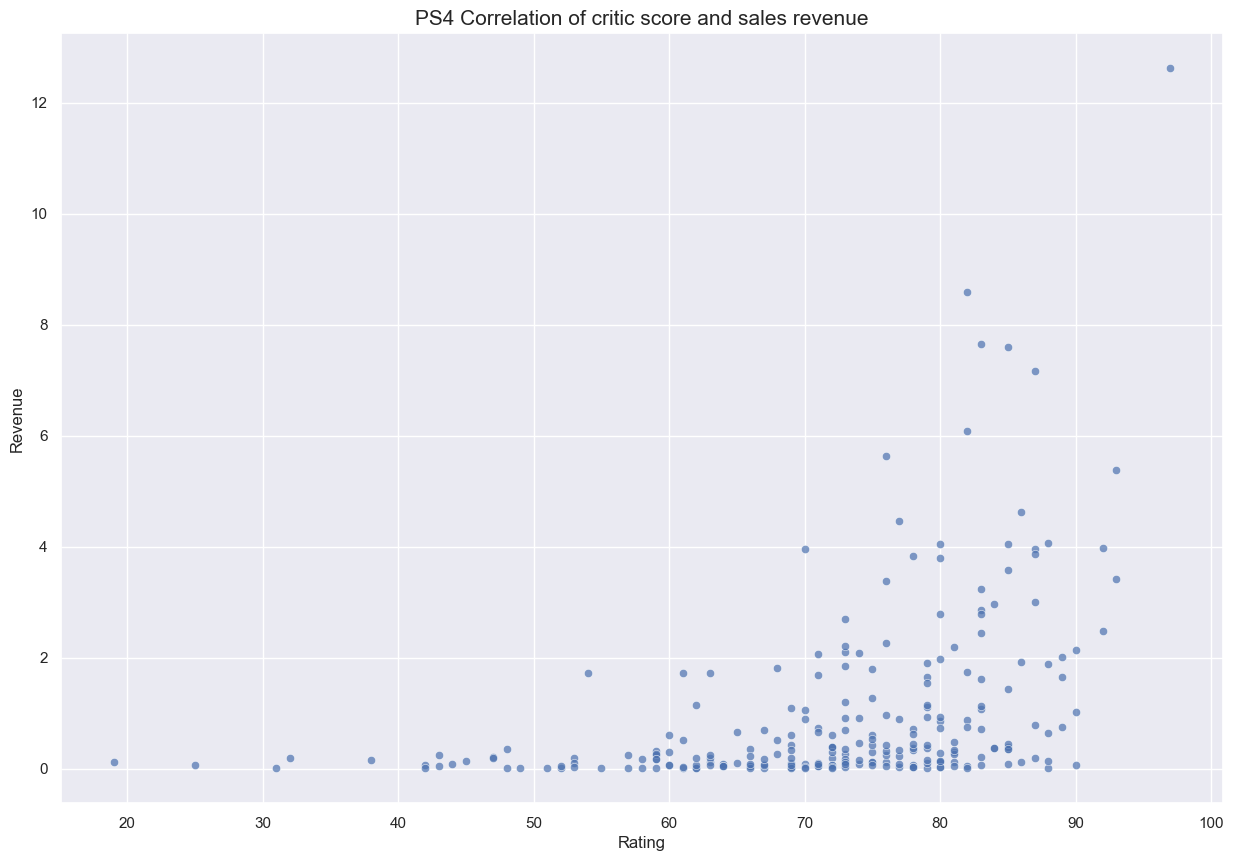

In [20]:
# %%
print("Positive correlation between Revenue and critics' rating for PS4")
plt.figure(figsize=(15, 10))
sns.scatterplot(x="critic_score", y="total_sales", data=PS4_df, alpha=0.7)
plt.ylabel('Revenue')
plt.xlabel('Rating')
plt.title('PS4 Correlation of critic score and sales revenue', size=15)


In [21]:
# %%
PS4_df['total_sales'].corr(PS4_df['user_score'])


-0.03362497596528887

A weak negative correlation between Revenue and users' rating for PS4


<Figure size 1500x1000 with 0 Axes>

<Axes: xlabel='user_score', ylabel='total_sales'>

Text(0, 0.5, 'Revenue')

Text(0.5, 0, 'Rating')

Text(0.5, 1.0, 'PS4 Correlation of user score and sales revenue')

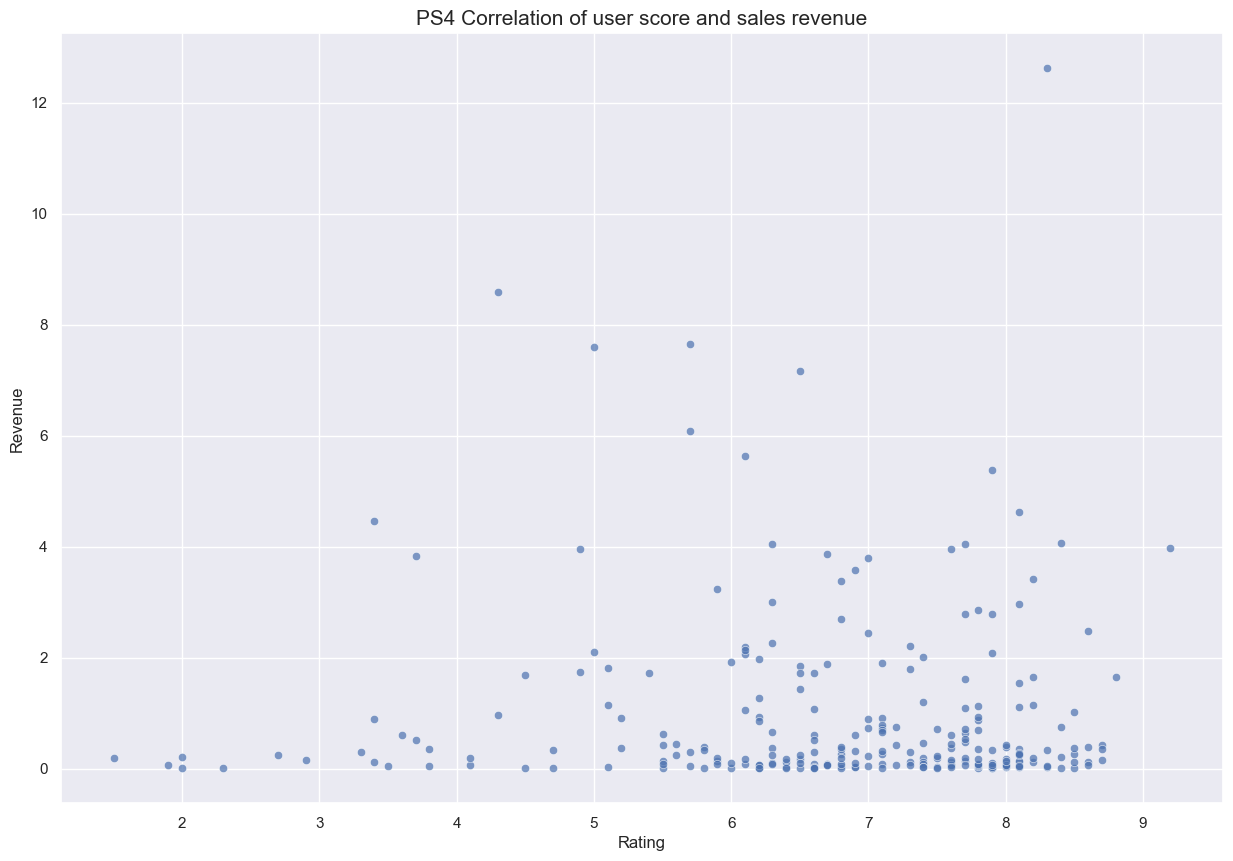

In [22]:
# %%
print("A weak negative correlation between Revenue and users' rating for PS4")
plt.figure(figsize=(15, 10))
sns.scatterplot(x="user_score", y="total_sales", data=PS4_df, alpha=0.7)
plt.ylabel('Revenue')
plt.xlabel('Rating')
plt.title('PS4 Correlation of user score and sales revenue', size=15)


 <div style="border:solid green 2px; padding: 20px"> <b>Success:</b><br>

     Wonderful visualization! 😊  Yep, the platform PS4 is the most popular.</div>

In [23]:
# %%
X360_df = good_data.groupby(
    ['platform', 'name'])[['total_sales', 'critic_score', 'user_score']].sum(
).query('platform == "X360" & critic_score > 0 & user_score > 0').reset_index(
)


In [24]:
# %%
X360_df['total_sales'].corr(X360_df['critic_score'])


0.3503445460228664

Positive correlation between Revenue and critics' rating for X360


<Figure size 1500x1000 with 0 Axes>

<Axes: xlabel='critic_score', ylabel='total_sales'>

Text(0, 0.5, 'Revenue')

Text(0.5, 0, 'Rating')

Text(0.5, 1.0, 'X360 Correlation of critic score and sales revenue')

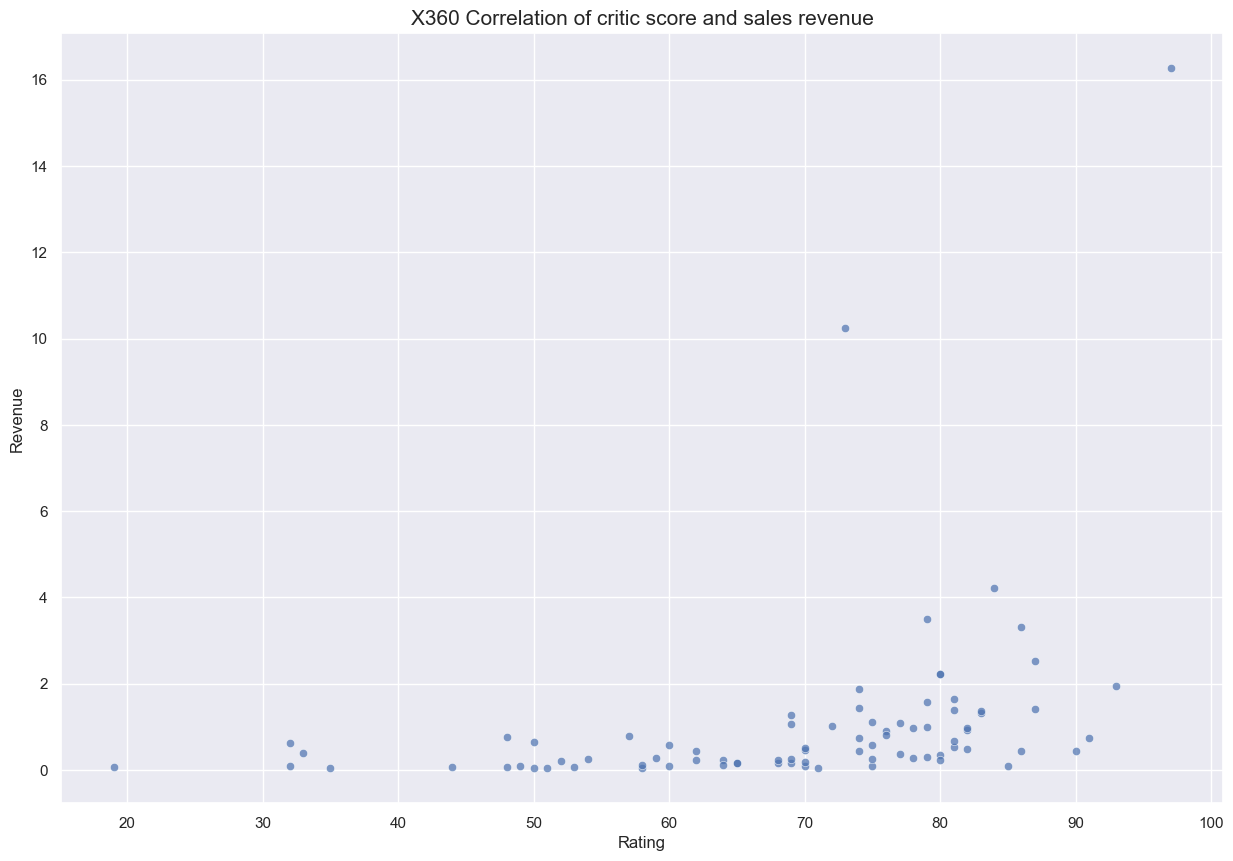

In [25]:
# %%
print("Positive correlation between Revenue and critics' rating for X360")
plt.figure(figsize=(15, 10))
sns.scatterplot(x="critic_score", y="total_sales", data=X360_df, alpha=0.7)
plt.ylabel('Revenue')
plt.xlabel('Rating')
plt.title('X360 Correlation of critic score and sales revenue', size=15)


In [26]:
# %%
X360_df['total_sales'].corr(X360_df['user_score'])


-0.006238179532306349

A weak positive correlation between Revenue and users' rating for X360


<Figure size 1500x1000 with 0 Axes>

<Axes: xlabel='user_score', ylabel='total_sales'>

Text(0, 0.5, 'Revenue')

Text(0.5, 0, 'Rating')

Text(0.5, 1.0, 'X360 Correlation of user score and sales revenue')

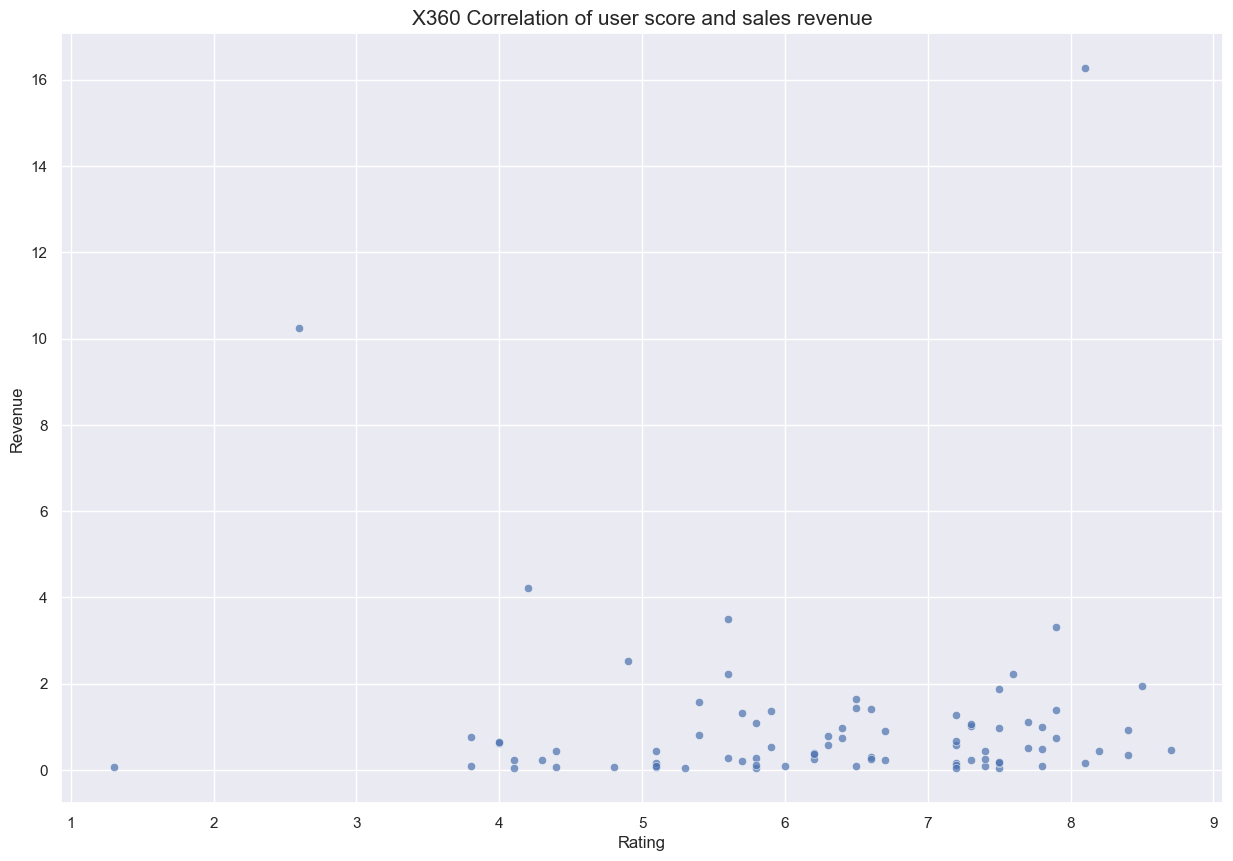

In [27]:
# %%
print("A weak positive correlation between Revenue and users' rating for X360")
plt.figure(figsize=(15, 10))
sns.scatterplot(x="user_score", y="total_sales", data=X360_df, alpha=0.7)
plt.ylabel('Revenue')
plt.xlabel('Rating')
plt.title('X360 Correlation of user score and sales revenue', size=15)


In [28]:
# %%


def corr_func(platform):
    data = good_data[good_data['platform'] == platform]
    corr = good_data[good_data['platform'] == platform][[
        'critic_score', 'user_score', 'total_sales']].corr()['total_sales']
    data.plot(y='total_sales', x='critic_score',
              kind='scatter', alpha=0.7, grid=True)
    plt.title(platform)
    data.plot(y='total_sales', x='user_score',
              kind='scatter', alpha=0.7, grid=True)
    plt.title(platform)
    print(platform, corr)
    print('-----')



PS4 critic_score    0.41
user_score     -0.03
total_sales     1.00
Name: total_sales, dtype: float64
-----
WiiU critic_score   0.38
user_score     0.42
total_sales    1.00
Name: total_sales, dtype: float64
-----
XOne critic_score    0.42
user_score     -0.07
total_sales     1.00
Name: total_sales, dtype: float64
-----
PS3 critic_score   0.33
user_score     0.00
total_sales    1.00
Name: total_sales, dtype: float64
-----
X360 critic_score    0.35
user_score     -0.01
total_sales     1.00
Name: total_sales, dtype: float64
-----
Wii critic_score    NaN
user_score     0.68
total_sales    1.00
Name: total_sales, dtype: float64
-----


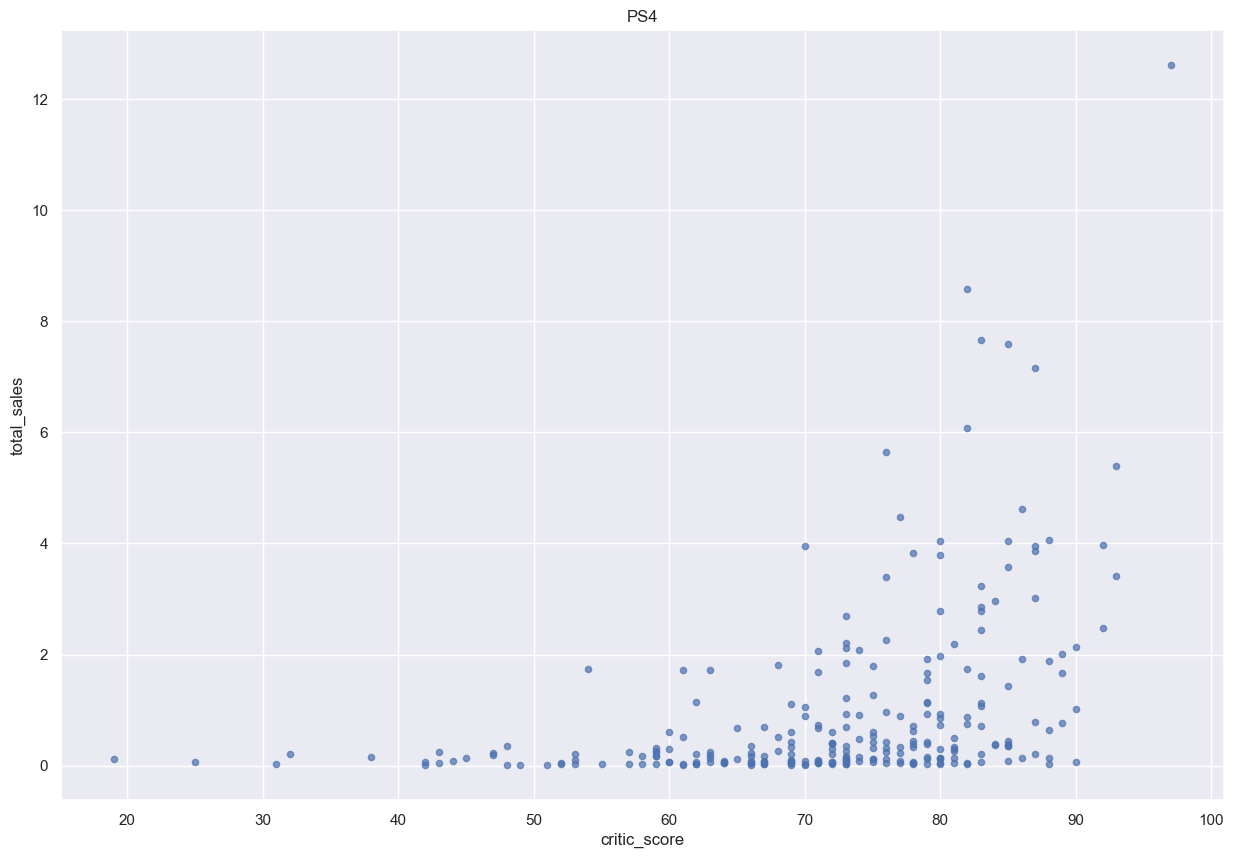

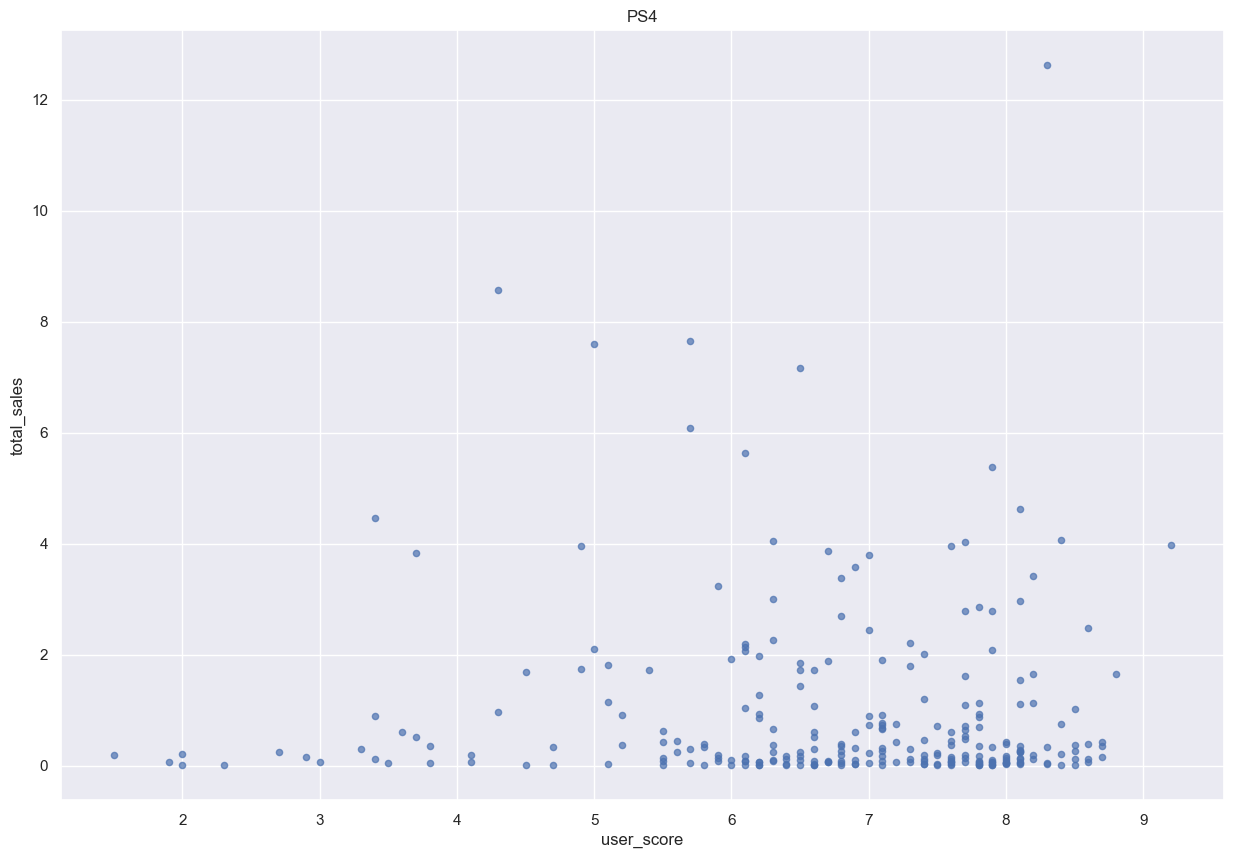

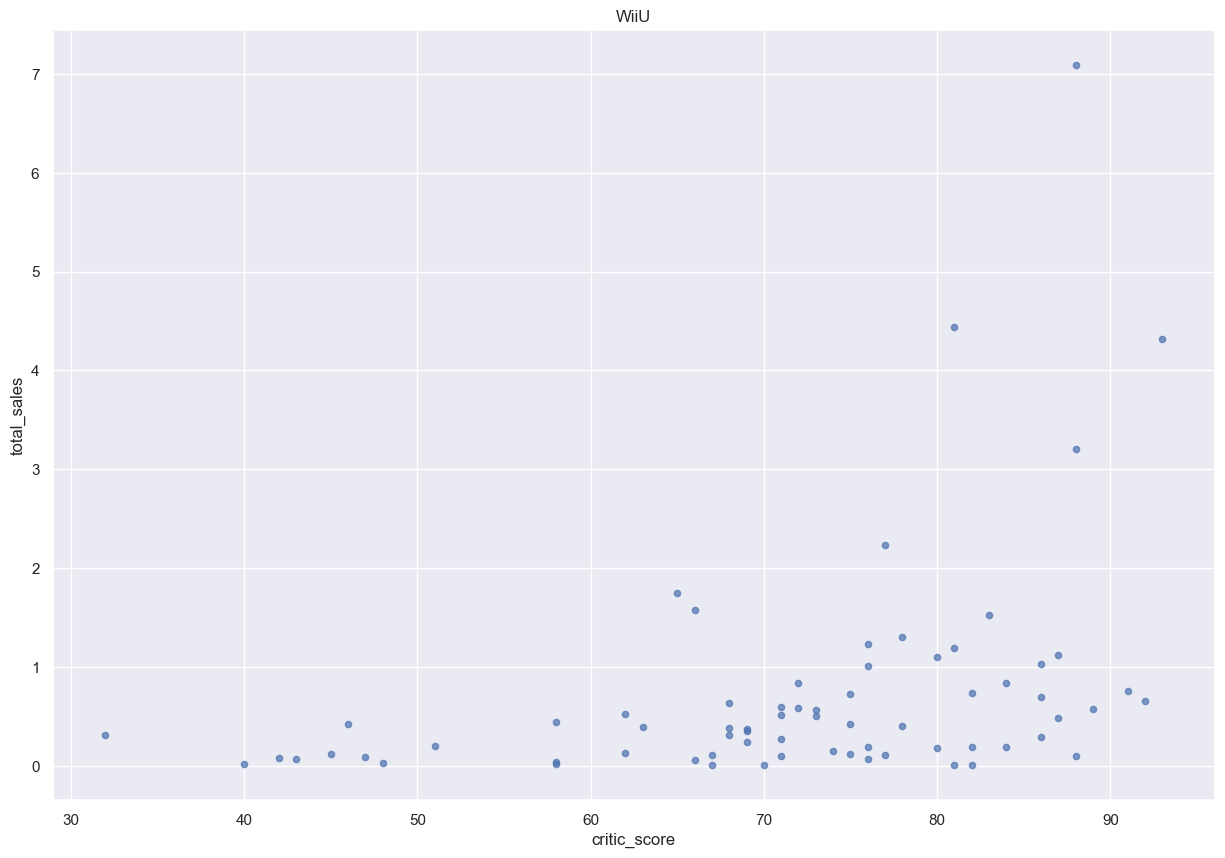

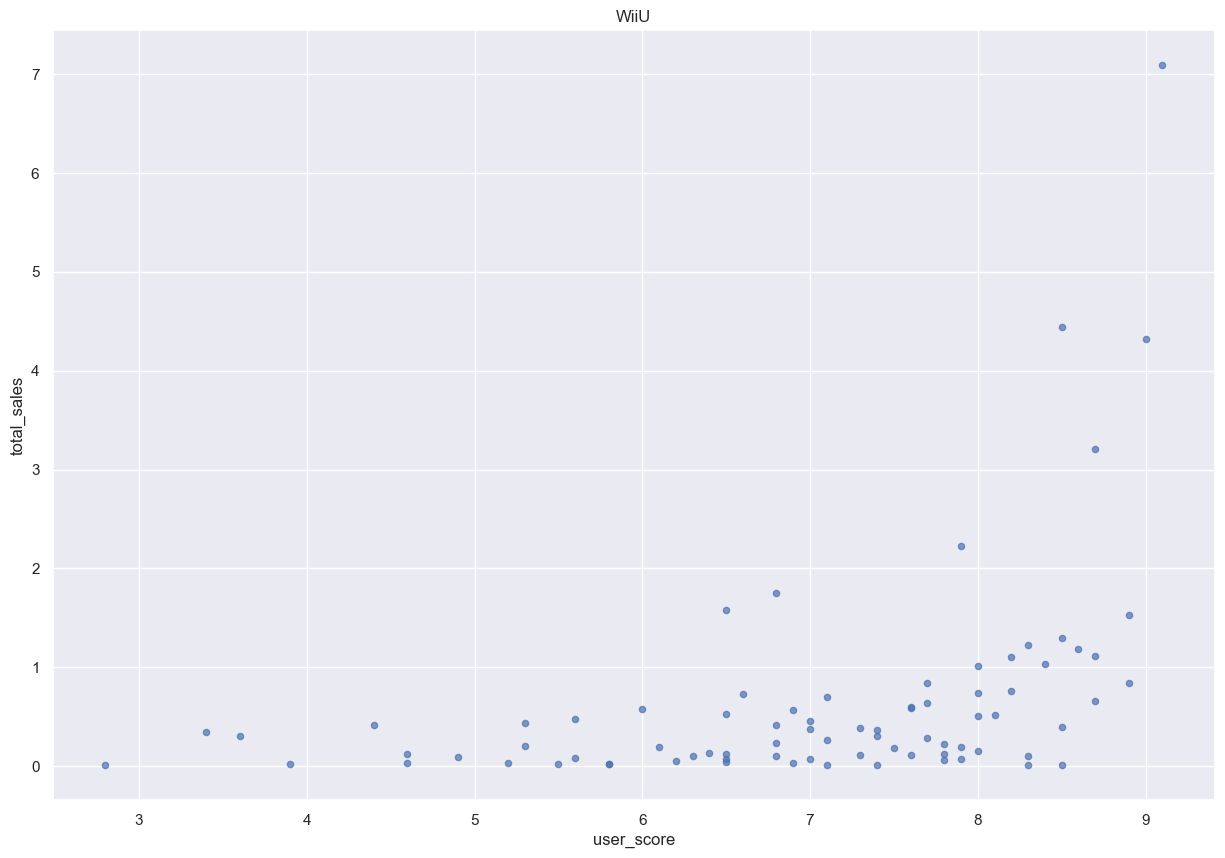

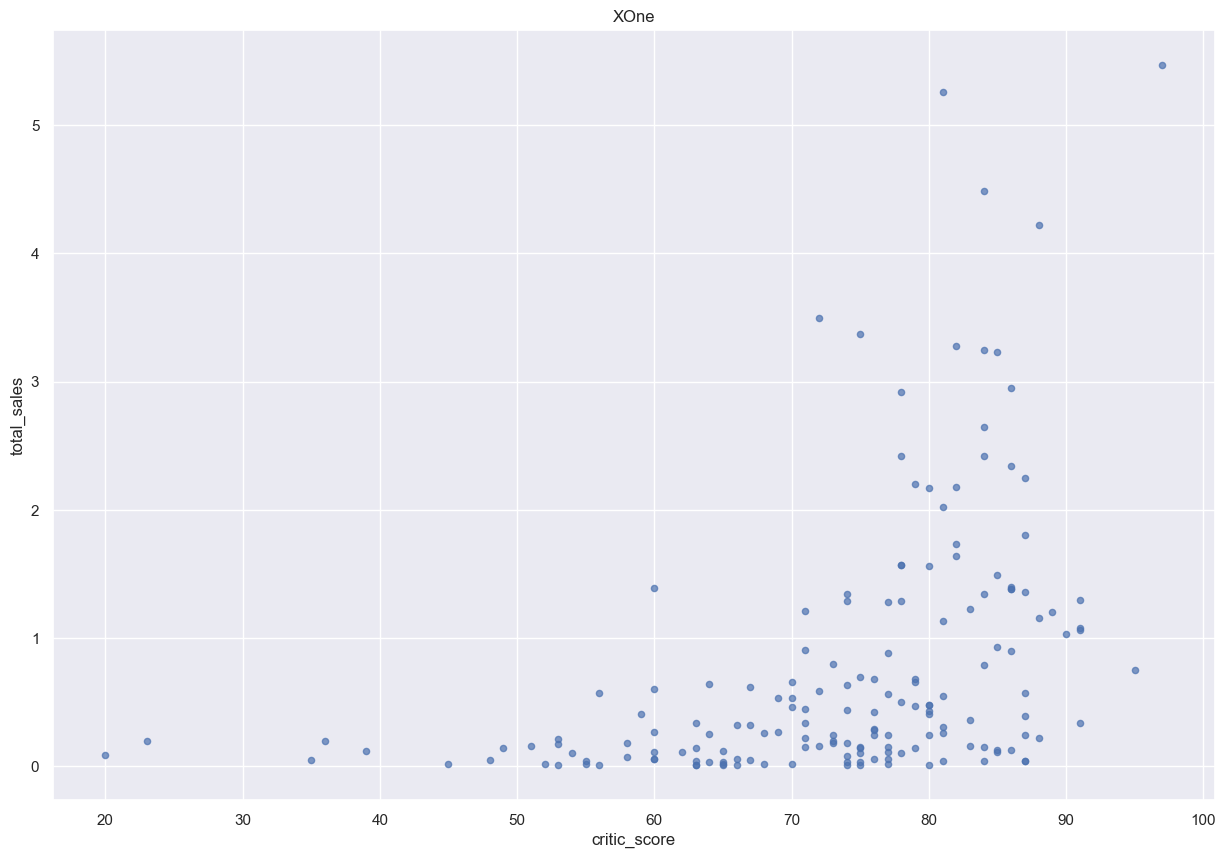

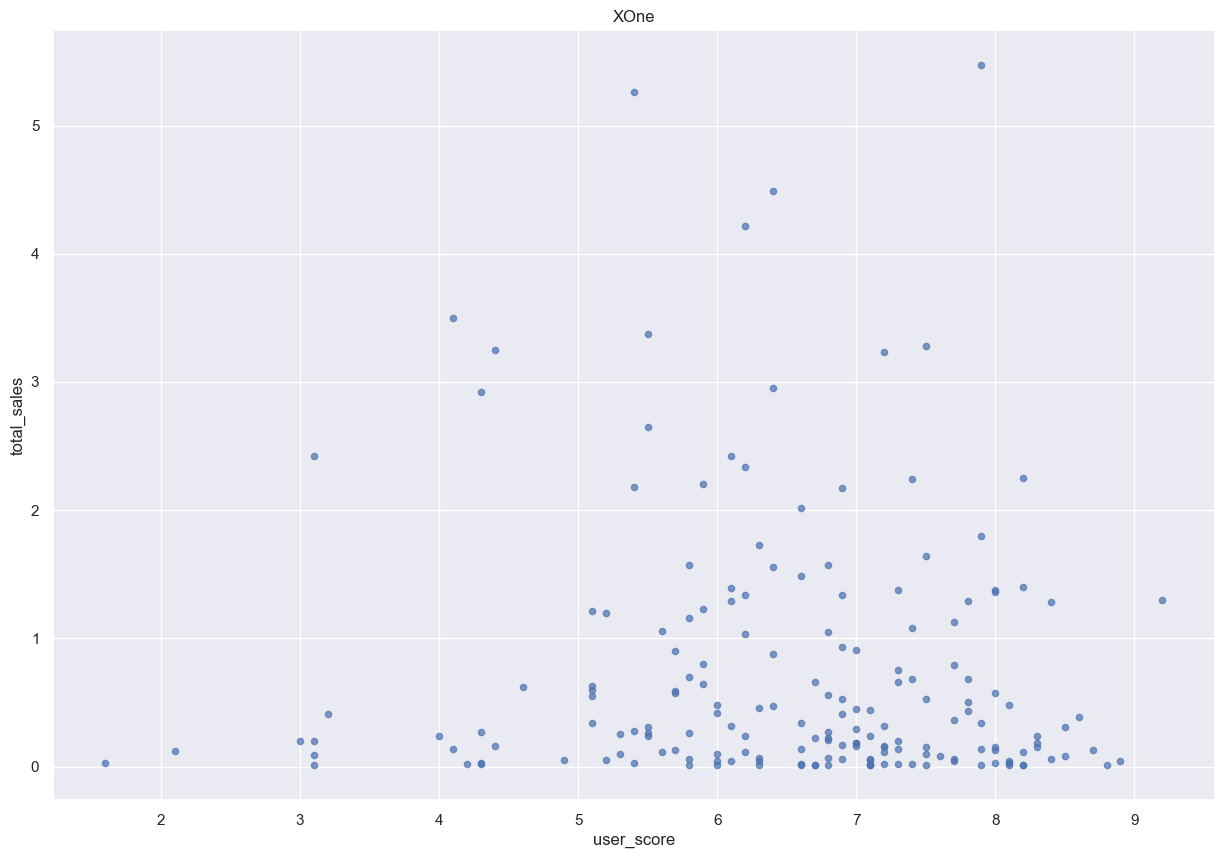

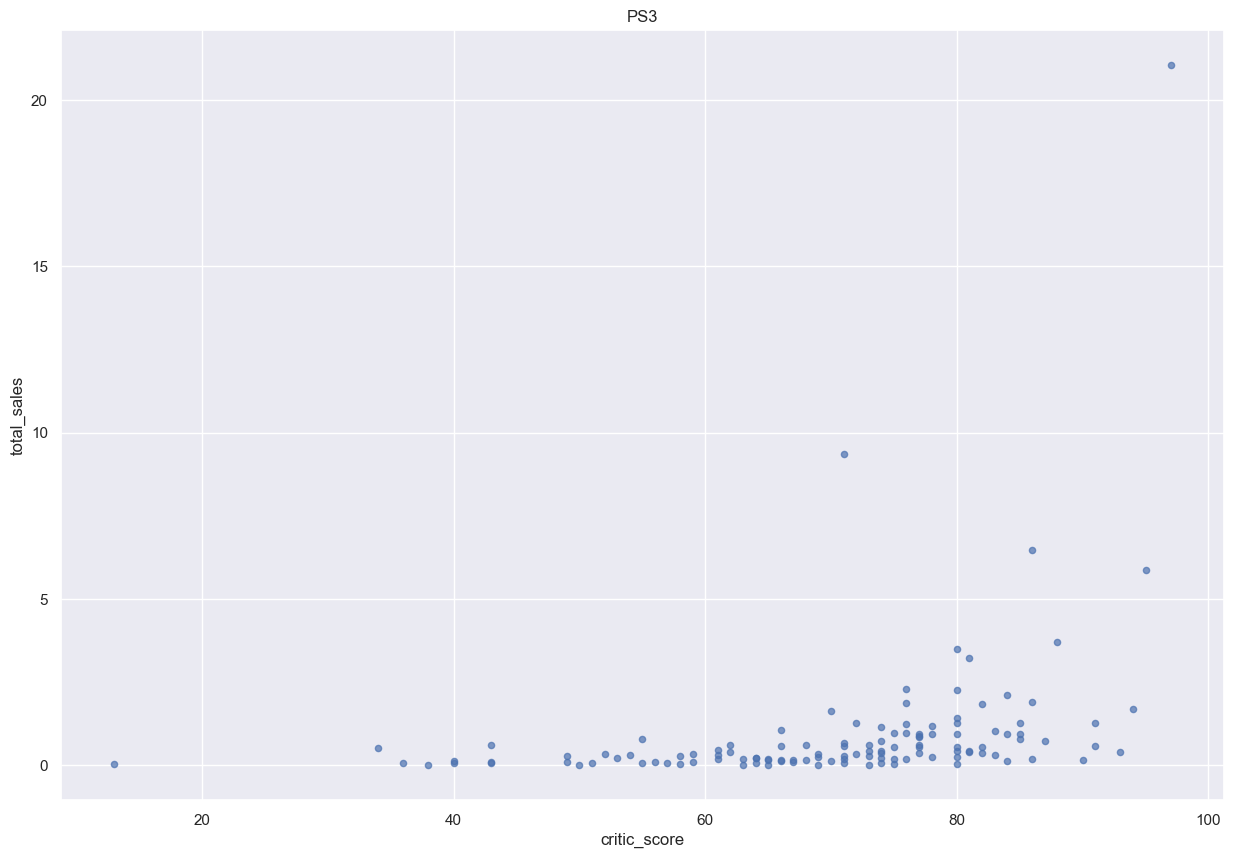

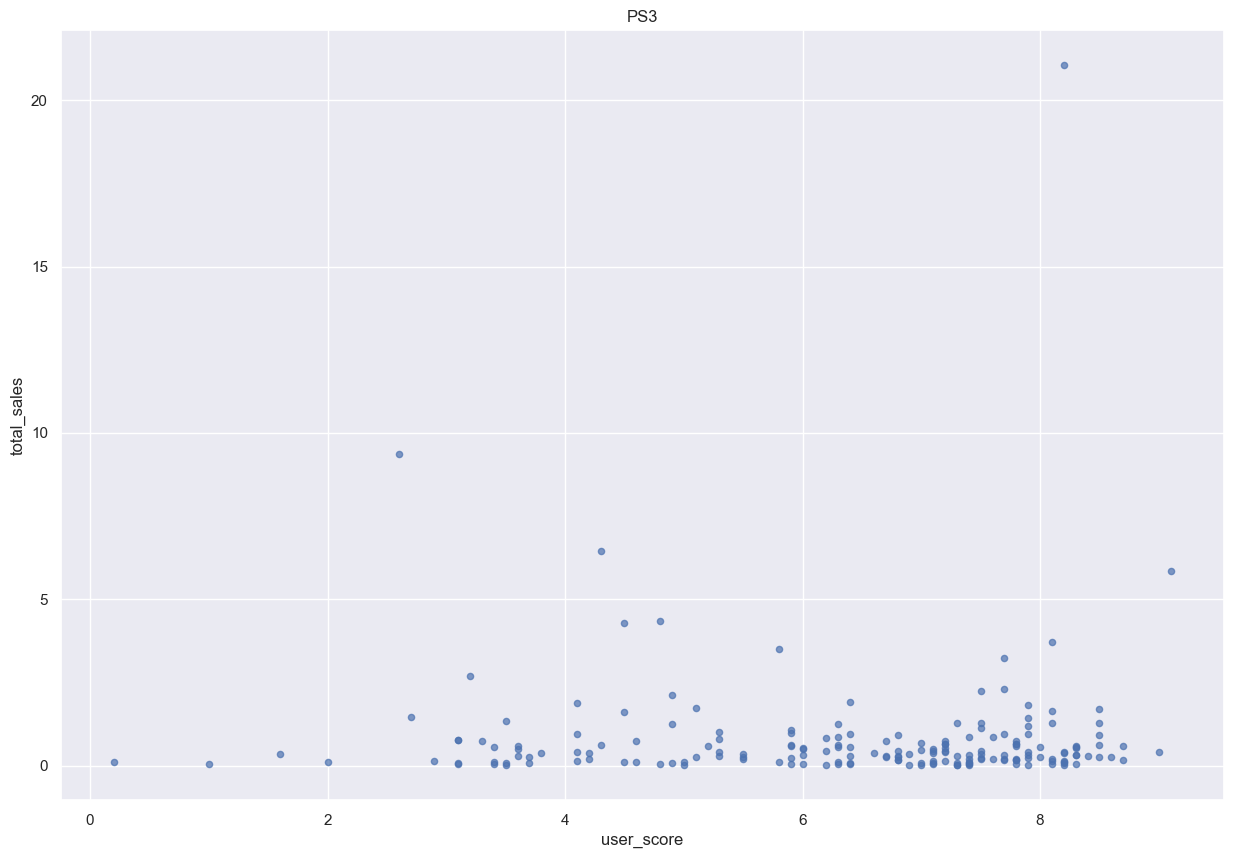

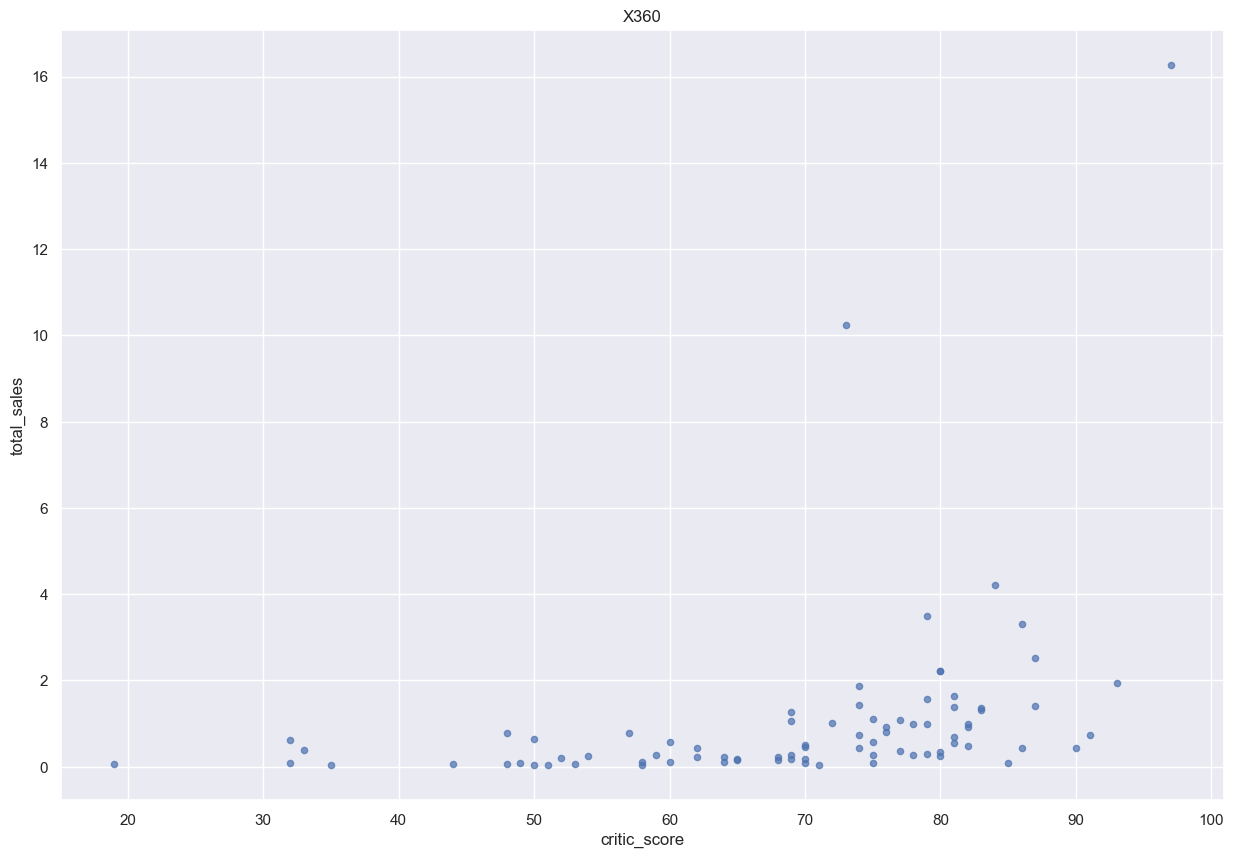

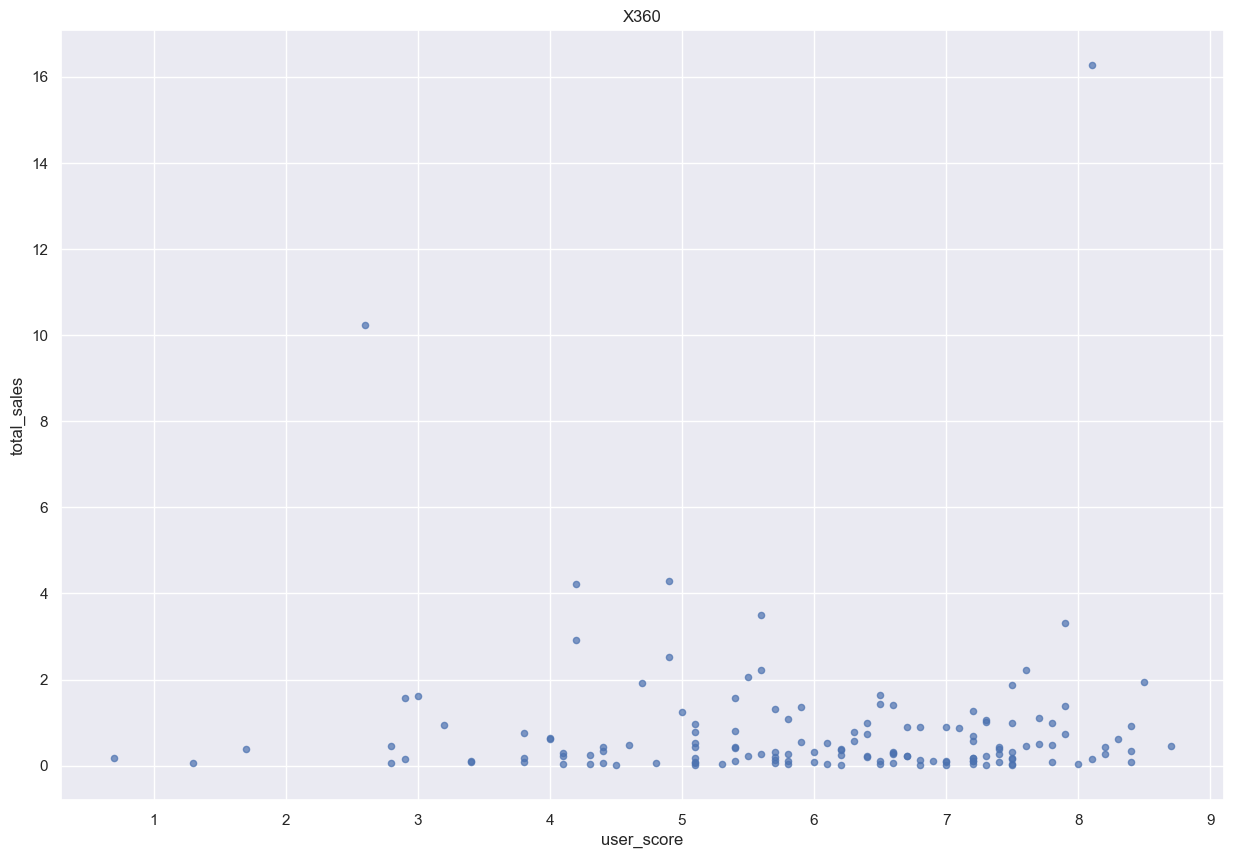

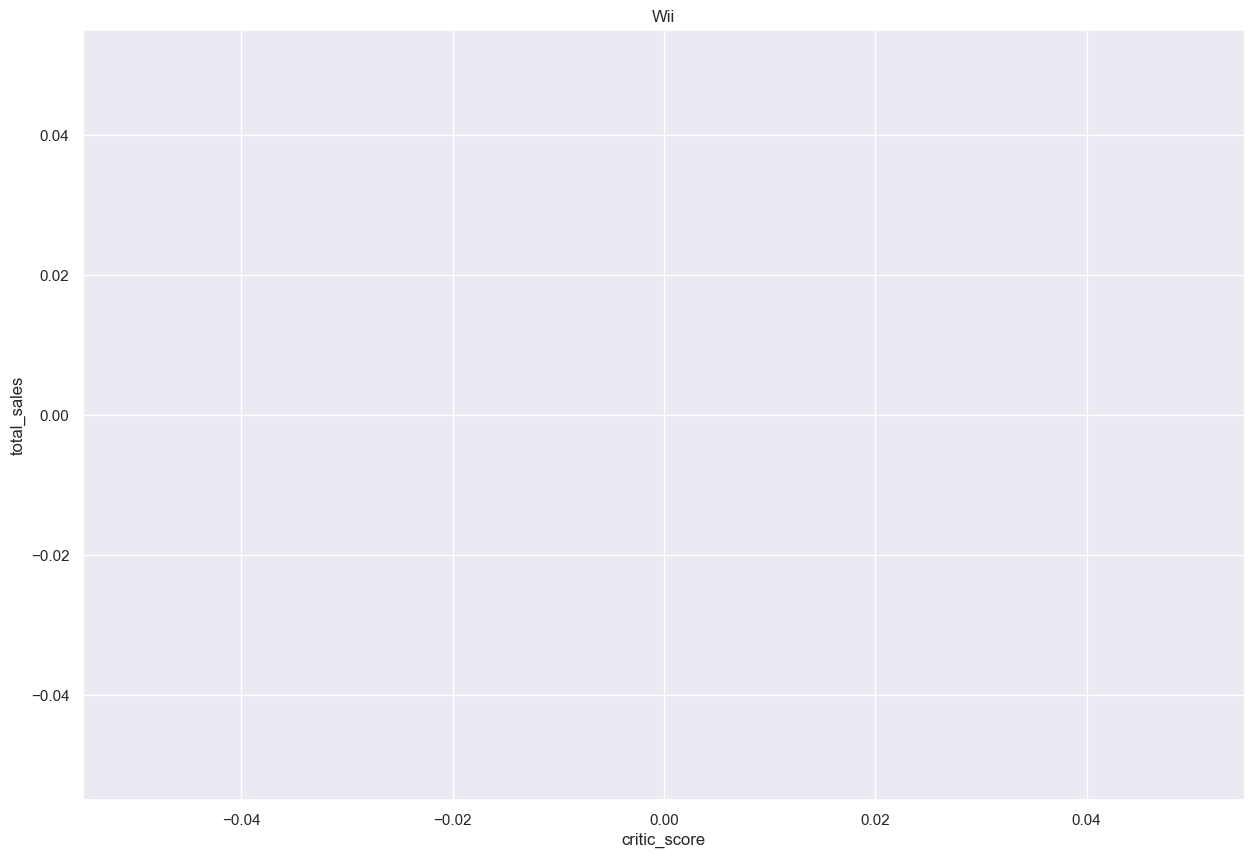

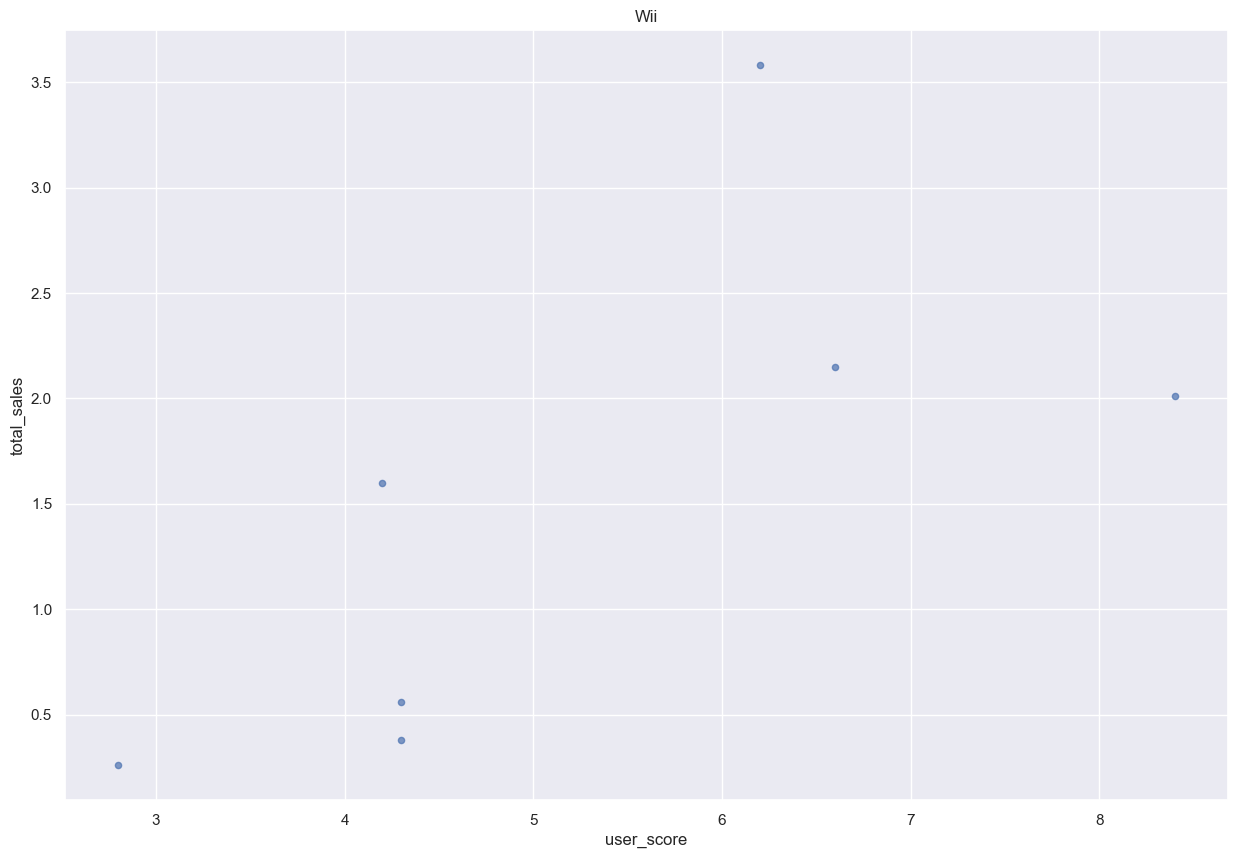

In [29]:
# %%
platforms = ['PS4', 'WiiU', 'XOne', 'PS3', 'X360', 'Wii']
for i in platforms:
    corr_func(i)


 #### Finding out how revenue is affected by genre

Almost all genres show good sales revenue


<Figure size 1500x1000 with 0 Axes>

<Axes: xlabel='genre', ylabel='total_sales'>

Text(0, 0.5, 'Revenue')

Text(0.5, 0, 'Genre')

Text(0.5, 1.0, 'Revenue distribution per game')

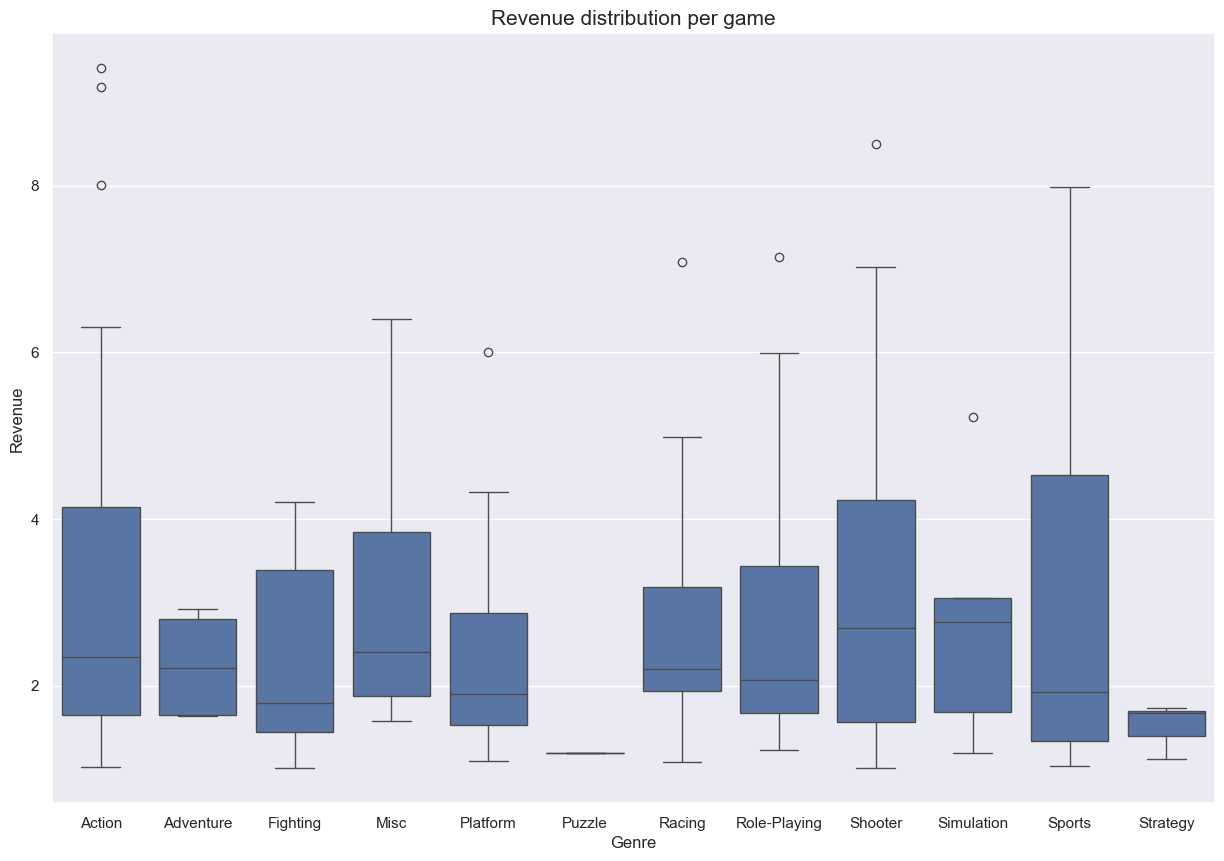

In [30]:
# %%
print('Almost all genres show good sales revenue')
df_genre = good_data.groupby(['genre', 'name'])[
    'total_sales'].sum().reset_index()
df_genre = df_genre.query('1<total_sales<10')
plt.figure(figsize=(15, 10))
sns.boxplot(x='genre', y='total_sales', data=df_genre)
plt.ylabel('Revenue')
plt.xlabel('Genre')
plt.title('Revenue distribution per game', size=15)


 #### Conclusion

 First we looked at game releases per year. We built a histogram and see that the distribution is skewed to the left. No wonder as the game industry began to grow rapidly in late 90’s.



 We grouped the data by platform and total revenue and calculated a z_score which shows for each platform how far total revenue is from the overall mean in terms of standard deviation. Then we built a graph showing the distribution of revenue for all the platforms.



 We also created a dataset showing a platform lifetime from the first sales to oblivion and built a lineplot showing this lifetime. We can see that on average a platform “lives” about 10 years before it completely fades away. Still that's a large period for decided to take the last ten years of data into consideration for our project as it will include all the relevant platforms.



 Using a lineplot for selected data we can see that the leading platforms in the last few years were PS3, PS4, XOne, X360 and 3DS. However, the graph shows that sales revenue for all platforms is declining.



 We built a boxplot based on selected data grouped by name and platform in order to determine how revenue is distributed across platforms. We found out that the platforms we chose previously are indeed the leading ones with higher total revenues and higher mean values than the rest. Except for WiiU platform that apparently has major outliers, namely Super Mario series which brought outstanding revenues to the platform in middle 2010’s.



 We chose two popular platforms - PS4 and X360 - to see how critic and user rating can affect sales. We built scatterplots for each case and we can see a robust positive correlation for critic reviews (nearly 0.4 for both platforms), i.e. higher score usually brings more revenue. However, the correlation between user score and revenue is about zero which means that sales revenue is not affected much by users’ opinion.



 Finally, we built a box plot to see how revenue is distributed among genres. We cut off the revenue outliers to have a closer look. We can see that all genres except Adventure, Puzzle and Strategy show good sales and high mean values. This might be the case because genres get mixed and a single game can be assigned multiple genres, like Action-Fighting or Simulation-Racing games.

 <div style="border:solid green 2px; padding: 20px"> <b>Success:</b><br>



 Great job! Especially impressed:



 - typical lifespan you determine correctly



 - z-score for the determining of the most popular platforms for the whole period



 - you have the titles and axes captions for all the graphs









 Thank you for in-depth analysis and logical conclusions! </div>

 ### Creating a user profile for each region

In [31]:
# %%
na_platform = good_data.groupby(
    ['platform'])['na_sales'].sum().reset_index().sort_values(by='na_sales', ascending=False
                                                              )
jp_platform = good_data.groupby(
    ['platform'])['jp_sales'].sum().reset_index().sort_values(by='jp_sales', ascending=False
                                                              )
eu_platform = good_data.groupby(
    ['platform'])['eu_sales'].sum().reset_index().sort_values(by='eu_sales', ascending=False
                                                              )
na_platform.sum()
na_platform.head()
eu_platform.sum()
eu_platform.head()
jp_platform.sum()
jp_platform.head()


platform    PS4XOneX360PS33DSWiiUPCWiiPSVDSPSP
na_sales                                437.71
dtype: object

,platform,na_sales
4,PS4,108.74
10,XOne,93.12
9,X360,81.66
3,PS3,63.50
0,3DS,38.20


platform    PS4PS3XOneX3603DSPCWiiUPSVWiiDSPSP
eu_sales                                392.23
dtype: object

,platform,eu_sales
4,PS4,141.09
3,PS3,67.81
10,XOne,51.59
9,X360,42.52
0,3DS,30.96


platform    3DSPS3PSVPS4WiiUPSPX360XOneWiiDSPC
jp_sales                                140.78
dtype: object

,platform,jp_sales
0,3DS,67.81
3,PS3,23.35
6,PSV,18.59
4,PS4,15.96
8,WiiU,10.88


 <div style="border:solid orange 2px; padding: 20px"> <b>Remarks:</b><br>

   For a clearer analysis of the game market in different regions it is better to use charts. For example, you can add pie plots or bar plots :)</div>

In [32]:
# %%
na_genre = good_data.groupby(
    ['genre'])['na_sales'].sum().reset_index().sort_values(by='na_sales', ascending=False).head()
jp_genre = good_data.groupby(
    ['genre'])['jp_sales'].sum().reset_index().sort_values(by='jp_sales', ascending=False).head()
eu_genre = good_data.groupby(
    ['genre'])['eu_sales'].sum().reset_index().sort_values(by='eu_sales', ascending=False).head()
na_genre.head()
eu_genre.head()
jp_genre.head()


,genre,na_sales
0,Action,126.05
8,Shooter,109.74
10,Sports,65.27
7,Role-Playing,46.40
3,Misc,27.49


,genre,eu_sales
0,Action,118.13
8,Shooter,87.86
10,Sports,60.52
7,Role-Playing,36.97
6,Racing,20.19


,genre,jp_sales
7,Role-Playing,51.04
0,Action,40.49
3,Misc,9.20
2,Fighting,7.65
8,Shooter,6.61


In [33]:
# %%
good_data.groupby(['rating'])[['na_sales', 'eu_sales', 'jp_sales']].agg(
    'sum').sort_values(by='na_sales', ascending=False)



,na_sales,eu_sales,jp_sales
rating,,,
M,165.21,145.32,14.11
E,79.05,83.36,15.14
E10+,54.24,42.69,5.89
T,49.79,41.95,20.59


 #### Conclusion

 We created multiple dataframes to see the top players on each market in terms of platform, genre and rating.



 First of all we looked at platforms and see that revenue is not equally distributed across the regions: NA brought 438 million to game developers in the respective period which is 3 times more than Japan. We can see that PS3 is doing better in EU region than in NA region and that XBox is not in top five in Japan. This might be because the market is special and relatively small and doesn't respond to global trends. We can see that top five platforms in Japan are originally local brands: Sony and Nintendo.



 Secondly, we looked at top five genres for each region and again NA and EU look alike except for the fifth place: Misc. (NA) vs. Racing (EU). Japan top five genres have Role-playing on top, Action is second and Shoter's the last.



 Finally, the ESRB rating for NA and EU regions are the same - "M", "E", "E10+", "T". This means that for these two regions the age of players has similar distribution.

 In Japan however the revenue distribution differs - "T" is on the 1st place, than "E" and "M".

 <div style="border:solid green 2px; padding: 20px"> <b>Success:</b><br>

     Technically everything is correct here, I really like your detailed conclusions, but due to the fact that the period previously selected was not actual, the platforms here are not quite up to date. As soon as you fix the actual period, everything will be okay here. Can you please write here your guesses as to what may be related similarities and differences in the most popular platforms in different regions?</div>

 ### Hypotheses testing

 #### Hypothesis 1: Average user ratings of the Xbox One and PC platforms are the same

<Axes: xlabel='user_score', ylabel='Count'>

Text(0, 0.5, 'Frequency')

Text(0.5, 0, 'Rating')

Text(0.5, 1.0, 'User rating distribution per platform')

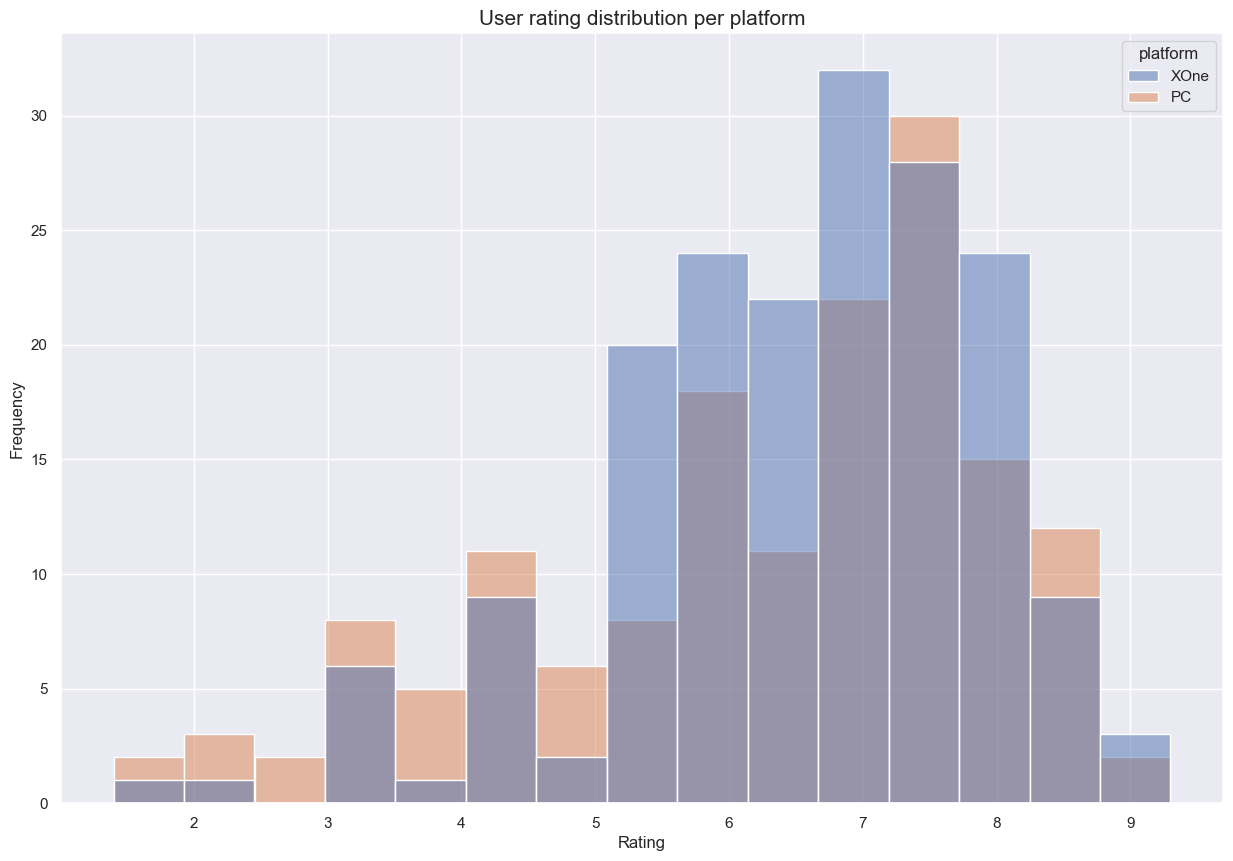

In [34]:
# %%
hyp_data = good_data.query(
    'user_score > 0 & platform == "XOne" or user_score > 0 & platform == "PC"')
fig, ax = plt.subplots(figsize=(15, 10))
sns.histplot(hyp_data, x='user_score', hue='platform')
plt.ylabel('Frequency')
plt.xlabel('Rating')
plt.title('User rating distribution per platform', size=15)


In [35]:
# %%
# Reviewer's code
hyp_data[(hyp_data['platform'] == 'PC') & (hyp_data['user_score'] == 0)]


,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales


Text(0, 0.5, 'Rating')

Text(0.5, 0, 'Platform')

Text(0.5, 1.0, 'User rating distribution per platform')

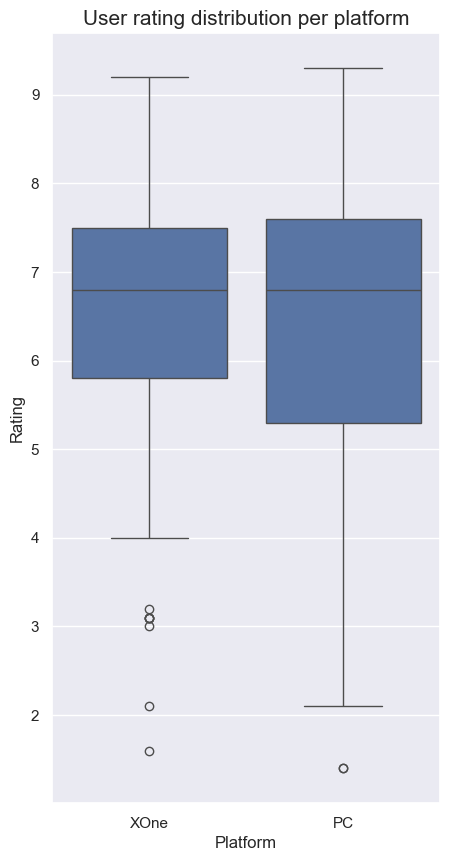

In [36]:
# %%
fig, ax = plt.subplots(figsize=(5, 10))
ax = sns.boxplot(x='platform', y='user_score', data=hyp_data)
plt.ylabel('Rating')
plt.xlabel('Platform')
plt.title('User rating distribution per platform', size=15)


 <div style="border:solid green 2px; padding: 20px"> <b>Success:</b><br>



  It's great that you visualized the sample distributions!  </div>

In [37]:
# %%
hyp_data.groupby(['platform'])['user_score'].agg('mean')


platform
PC     6.27
XOne   6.52
Name: user_score, dtype: float64

In [38]:
# %%
XOne_df = hyp_data.query('platform == "XOne"')
PC_df = hyp_data.query('platform == "PC"')


 **We formulate the hypotheses as follows:**



  - Null-hypothesis: There are no statistically significant differences between the average user ratings of Xbox One and PC platforms;

  - Alternative hypothesis: The differences between average user ratings of the Xbox One and PC platforms are statistically significant.



 *We choose alpha parameter equal **5%** as a standart threshold for our kind of business.*

In [39]:
# %%
alpha = 0.05


In [40]:
# %%
p_value_levene = stats.levene(
    XOne_df['user_score'], PC_df['user_score']).pvalue
if p_value_levene < alpha:
    print('Reject H0: variance of sample 1 is not equal to variance of sample 2')
else:
    print("Fail to Reject H0: We don't have enough evidence to say that variances of sample 1 and sample 2 are not the same")


Reject H0: variance of sample 1 is not equal to variance of sample 2


In [41]:
# %%
p_value = stats.ttest_ind(
    XOne_df['user_score'], PC_df['user_score'], nan_policy='omit', equal_var=False).pvalue
if p_value < alpha:
    print("Reject H0: There are statistically significant differences between the average average user ratings of Xbox One and PC platforms.")
else:
    print("Fail to Reject H0: We don't have enough evidence to say that the difference between average user ratings of the Xbox One and PC platforms is statistically insignificant.")
p_value


Fail to Reject H0: We don't have enough evidence to say that the difference between average user ratings of the Xbox One and PC platforms is statistically insignificant.


0.14759594013430466

 #### Hypothesis 2: Average user ratings for the Action and Sports genres are the same

<Axes: xlabel='user_score', ylabel='Count'>

Text(0, 0.5, 'Frequency')

Text(0.5, 0, 'Rating')

Text(0.5, 1.0, 'User rating distribution per genre')

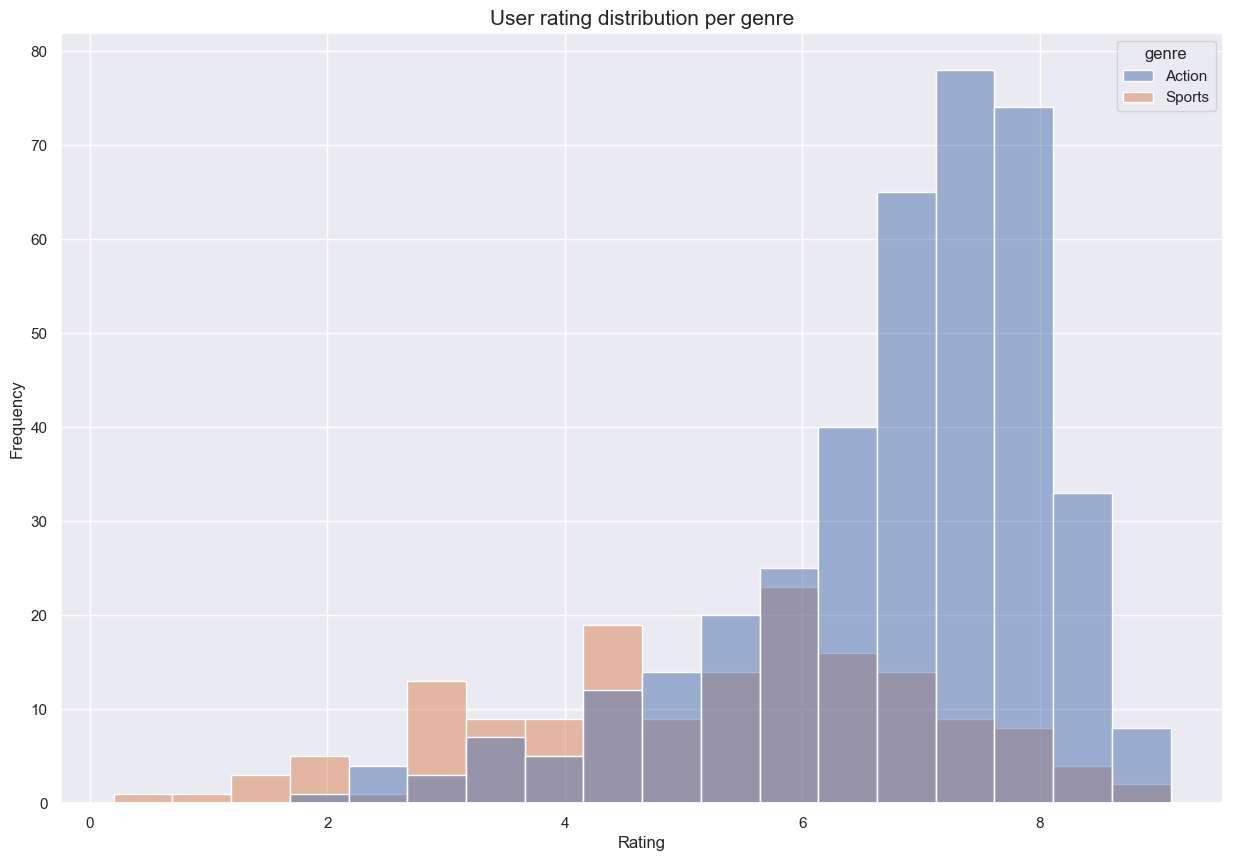

In [42]:
# %%
hyp_data2 = good_data.query(
    'user_score > 0 & genre == "Sports" or user_score > 0 & genre == "Action"')
fig, ax = plt.subplots(figsize=(15, 10))
sns.histplot(hyp_data2, x='user_score', hue='genre')
plt.ylabel('Frequency')
plt.xlabel('Rating')
plt.title('User rating distribution per genre', size=15)


Text(0, 0.5, 'Rating')

Text(0.5, 0, 'Genre')

Text(0.5, 1.0, 'User rating distribution per platform')

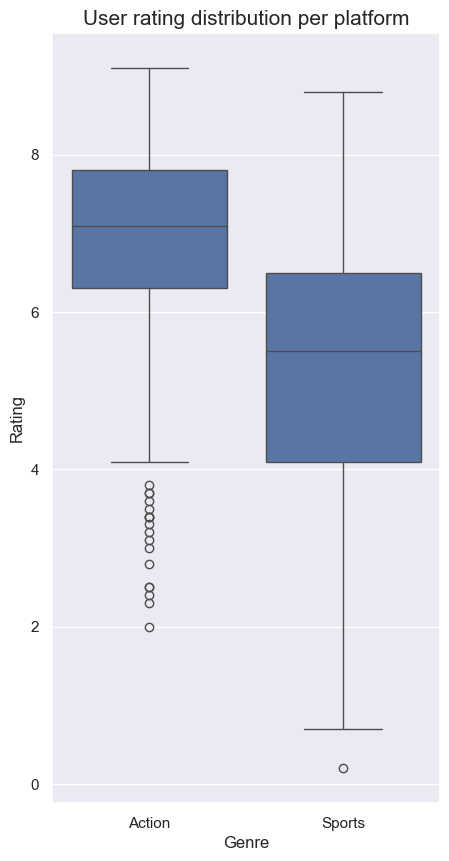

In [43]:
# %%
fig, ax = plt.subplots(figsize=(5, 10))
ax = sns.boxplot(x='genre', y='user_score', data=hyp_data2)
plt.ylabel('Rating')
plt.xlabel('Genre')
plt.title('User rating distribution per platform', size=15)


In [44]:
# %%
hyp_data2.groupby(['genre'])['user_score'].agg('mean')


genre
Action   6.84
Sports   5.24
Name: user_score, dtype: float64

In [45]:
# %%
Sports_df = hyp_data2.query('genre == "Sports"')
Action_df = hyp_data2.query('genre == "Action"')


 **We formulate the hypotheses as follows:**



  - Null-hypothesis: Average user ratings for the Action and Sports genres belong to the same statistical population;

  - Alternative hypothesis: Average user ratings for the Action and Sports genres do not belong to the same statistical population.



 *We choose alpha parameter equal **5%** as a standart threshold for our kind of business.*

In [46]:
# %%
alpha = 0.05


In [47]:
# %%
p_value_levene = stats.levene(
    Sports_df['user_score'], Action_df['user_score']).pvalue
if p_value_levene < alpha:
    print('Reject H0: variance of sample 1 is not equal to variance of sample 2')
else:
    print("Fail to Reject H0: We don't have enough evidence to say that variances of sample 1 and sample 2 are not the same")


Reject H0: variance of sample 1 is not equal to variance of sample 2


In [48]:
# %%
p_value = stats.ttest_ind(
    Sports_df['user_score'], Action_df['user_score'], nan_policy='omit', equal_var=False).pvalue
if p_value < alpha:
    print("Reject H0: Average user ratings for the Action and Sports genres do not belong to the same statistical population.")
else:
    print("Fail to Reject H0: We don't have enough evidence to say that average user ratings for the Action and Sports genres belong to different statistical populations.")
p_value


Reject H0: Average user ratings for the Action and Sports genres do not belong to the same statistical population.


1.4460039700704315e-20

 #### Conclusion

 We formulated and run the tests on both hypotheses and see that in the first case we failed to reject the null-hypothesis and in the second case we rejected the null-hypothesis.

 ### Overall conclusion

 **Working on the dataset**



 Our goal was to study the data, analyze the aspects affecting sales revenue of games in order to spot potential winners. We've got a dataset that contained name of the game, year of release, platform, genre, sales revenue in different regions and different ratings. We examined the datasets and discovered some weired data and some missing data.



 **Data preprocessing**



 We lowered the case for headers and changed data type for Year_of_release column.

 We dealt with the missing values in the following way:



    *Year_of_release*: We don't have many missing values here so we changed them to zero as it doesn't affect the results of our analysis.



    *Critic_score*: we looked for games with same names but missing score and filled it. We changed the rest to zero as there's nothing we can do to fill it in.



    *User_score*: again we looked for games with same names but missing score and filled it. However here we had to first create a separate dataframe that would not contain 'tbd' values. As well as we did previously, we changed the rest of 'NaN' and 'tbd' values to zero as there's nothing we can do to fill them in.



 We leave the other missing values as they are because those are object data types that we can not fill in. Still they might not have any visible impact on the results of our analysis.



 Finally we calculated Total_sales column as requested.



 **Making calculations**



 First we looked at game releases per year. We built a histogram and see that the distribution is skewed to the left. No wonder as the game industry began to grow rapidly in late 90’s.



 We grouped the data by platform and total revenue and calculated a z_score which shows for each platform how far total revenue is from the overall mean in terms of standard deviation. Then we built a graph showing the distribution of revenue for all the platforms.



 We also created a dataset showing a platform lifetime from the first sales to oblivion and built a lineplot showing this lifetime. We can see that on average a platform “lives” about 10 years before it completely fades away and decided to take the last ten years of data into consideration for our project as it will include all the relevant platforms.



 Using a lineplot for selected data we can see that the leading platforms in the last few years were PS3, PS4, XOne, X360 and 3DS. However, the graph shows that sales revenue for all platforms is declining.



 We built a boxplot based on selected data grouped by name and platform in order to determine how revenue is distributed across platforms. We found out that the platforms we chose previously are indeed the leading ones with higher total revenues and higher mean values than the rest. Except for WiiU platform that apparently has major outliers, namely Super Mario series which brought outstanding revenues to the platform in middle 2010’s.



 We chose two popular platforms - PS4 and X360 - to see how critic and user rating can affect sales. We built scatterplots for each case and we can see a robust positive correlation for critic reviews (nearly 0.4 for both platforms), i.e. higher score usually brings more revenue. However, the correlation between user score and revenue is about zero which means that sales revenue is not affected much by users’ opinion.



 Finally, we built a box plot to see how revenue is distributed among genres. We cut off the revenue outliers to have a closer look. We can see that all genres except Adventure, Puzzle and Strategy show good sales and high mean values. This might be the case because genres get mixed and a single game can be assigned multiple genres, like Action-Fighting or Simulation-Racing games.



 **Creating a user profile for each region**



 First of all we looked at platforms and see that revenue is not equally distributed across the regions: NA brought 438 million to game developers in the respective period which is 3 times more than Japan. We can see that PS3 is doing better in EU region than in NA region and that XBox is not in top five in Japan. This might be because the market is special and relatively small and doesn't respond to global trends. We can see that top five platforms in Japan are originally local brands: Sony and Nintendo.



 Secondly, we looked at top five genres for each region and again NA and EU look alike except for the fifth place: Misc. (NA) vs. Racing (EU). Japan top five genres have Role-playing on top, Action is second and Shoter's the last.



 Finally, the ESRB rating for NA and EU regions are the same - "M", "E", "E10+", "T". This means that for these two regions the age of players has similar distribution.

 In Japan however the revenue distribution differs - "T" is on the 1st place, than "E" and "M".



 **Testing hypotheses**



 We formulated and tested the following hypotheses:

 1. Average user ratings of the Xbox One and PC platforms are the same.

 2. Average user ratings for the Action and Sports genres are the same.



 We chose alpha parameter equal to 5% as it is a standard for this type of busines and everything falling below this threshold can be considered accidential.



 As a result we failed to reject the first null-hypothesis meaning ***we don't have enough evidense to state whether the average user ratings of the Xbox One and PC platforms are not the same.***



 And the second null-hypothesis was rejected which means that in the second case ***the average user ratings for the Action and Sports genres are not the same.***



 **Our conclusion**



 We can draw the following conclusions:

 1. The lifetime of a platform is about 10 years;

 2. The most profitable platforms in the chosen period are those made by Microsoft, Sony and Nintendo;

 3. Sales revenue usually depends on critics' score and does not depend on users' opinion;

 4. The trending genres are Action, Shooter, Sports and Role-playing;

 5. In order to succeed the ESRB rating must be either "E" or "M".

 <div style="border:solid green 2px; padding: 20px"> <b>Success:</b><br>

    I like that you wrote such in-depth conclusions on the whole study, proved them with numbers and made logical assumptions. Thank you for your work! It's really great! 👏👏👏</d